# Eye-Tracking Analysis Pipeline

This notebook combines the entire data processing, exploration, and statistical analysis workflow for the Active/Passive Voice eye-tracking experiment. 

Before running the cells, please ensure your working directory is the root of the project (`Active_passive_eyetracking`).

**Important Note:** The code in this notebook has been refactored from standalone scripts to:
1. Prevent redundant loading and saving of the exact same CSVs across cells. Dataframes created in Step 1 will persist in memory through Step 11.
2. Fix hardcoded screen dimensional limits that flagged outliers (`> 2000` pixels).
3. Ensure consistent logic for categorizing `"Active"` and `"Passive"` voices based on `voice_id` starting from Step 2, rather than repeating it later.
4. Stop reclassifying unassigned `"other"` Area-of-Interest fixations generically into the `"subject"` label (which artificially inflates subject-fixation counts).
5. Output visual distributions directly inline, replacing `plt.close()` with `plt.show()`.


## Setup & Imports

Run this cell first to import necessary libraries, set the correct working directory, and create all required directories for plots and results.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact
from datetime import datetime

# Set working directory to project root if not already there
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")

# Create required output directories
for d in ["data/processed", "plots/exploratory", "results/exploratory", 
          "results/reports", "results/comparisons", "plots/comparisons",
          "results/first_fixation", "plots/first_fixation", 
          "results/first_non_center_fixation", "plots/first_non_center_fixation",
          "results/total_fixations", "plots/total_fixations",
          "results/active_passive_correlation", "plots/active_passive_correlation"]:
    os.makedirs(d, exist_ok=True)

# Set matplotlib style globally
plt.style.use('default')
sns.set_palette("husl")


## Step 1: Load and Clean Data

This section loads the raw Fixation, Interest Area, and Saccade reports. It extracts participant IDs, selects the relevant variables, standardizes data types, and saves the cleaned datasets.


In [2]:
# %% Data Loading and Initial Cleaning
# Script: 01_load_and_clean_data.py
# Purpose: Load all Excel files from three report types, extract participant IDs,
#          select relevant variables, and perform initial cleaning

from pathlib import Path



# %% Define file paths
fixation_dir = "reports/fixation"
interest_area_dir = "reports/interest_area"
saccade_dir = "reports/saccade_reports"

# %% Function to extract participant ID from filename
def extract_participant_id(filename):
    """
    Extract participant ID from filename.
    Pattern: edf##_YYYY_MM_DD_HH_MM.xls or P##_YYYY_MM_DD_HH_MM.xls
    """
    pattern = r"(edf\d+|P\d+)_\d{4}_\d{2}_\d{2}_\d{2}_\d{2}\.xls"
    match = re.search(pattern, filename)
    if match:
        # Extract the participant ID part (edf## or P##)
        participant_id = re.search(r"(edf\d+|P\d+)", match.group(0))
        if participant_id:
            return participant_id.group(0)
    return None

# %% Load Fixation Reports
print("Loading fixation reports...")
fixation_files = [f for f in Path(fixation_dir).glob("*.xls")]
print(f"Found {len(fixation_files)} fixation files")

fixation_data_list = []

for i, file_path in enumerate(fixation_files, 1):
    filename = file_path.name
    participant_id = extract_participant_id(filename)
    
    if participant_id is None:
        print(f"Warning: Could not extract participant ID from {filename}")
        continue
    
    try:
        # Read file - these are actually tab-separated UTF-16 files, not Excel
        # Try reading as UTF-16 tab-separated first, fall back to Excel if that fails
        try:
            df = pd.read_csv(file_path, sep='\t', encoding='utf-16-le', dtype=str, low_memory=False)
        except (UnicodeDecodeError, pd.errors.ParserError):
            # Fallback to Excel reader
            df = pd.read_excel(file_path, dtype=str, engine='xlrd')
        
        # Add participant ID and filename
        df['participant_id'] = participant_id
        df['data_file'] = filename
        
        # Select relevant variables from fixation reports
        relevant_vars = [
            # Participant and trial identifiers
            "participant_id", "data_file", "TRIAL_INDEX", "TRIAL_LABEL", "TRIAL_START_TIME",
            # Fixation metrics
            "CURRENT_FIX_DURATION", "CURRENT_FIX_INDEX", "CURRENT_FIX_START", "CURRENT_FIX_END",
            "CURRENT_FIX_X", "CURRENT_FIX_Y",
            # Interest area information
            "CURRENT_FIX_INTEREST_AREA_LABEL", "CURRENT_FIX_INTEREST_AREA_ID",
            "CURRENT_FIX_INTEREST_AREA_INDEX", "CURRENT_FIX_INTEREST_AREA_DWELL_TIME",
            "CURRENT_FIX_INTEREST_AREA_FIX_COUNT",
            # Trial-level information
            "TRIAL_FIXATION_TOTAL", "sentence", "voice_id", "image_id", "stim_id",
            "image", "stimulus_file", "session_var", "exp_id", "language", "audio"
        ]
        
        # Select only variables that exist in the dataframe
        vars_to_select = [v for v in relevant_vars if v in df.columns]
        df_selected = df[vars_to_select].copy()
        
        # Convert numeric columns
        numeric_cols = [
            "CURRENT_FIX_DURATION", "CURRENT_FIX_INDEX", "CURRENT_FIX_START",
            "CURRENT_FIX_END", "CURRENT_FIX_X", "CURRENT_FIX_Y",
            "TRIAL_INDEX", "TRIAL_START_TIME", "TRIAL_FIXATION_TOTAL",
            "CURRENT_FIX_INTEREST_AREA_ID", "CURRENT_FIX_INTEREST_AREA_INDEX",
            "CURRENT_FIX_INTEREST_AREA_DWELL_TIME", "CURRENT_FIX_INTEREST_AREA_FIX_COUNT"
        ]
        
        for col in numeric_cols:
            if col in df_selected.columns:
                df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')
        
        fixation_data_list.append(df_selected)
        
        if i % 10 == 0:
            print(f"Processed {i}/{len(fixation_files)} fixation files")
    except Exception as e:
        print(f"Error reading {filename}: {str(e)}")

# Combine all fixation data (filter out None entries)
fixation_data_list = [df for df in fixation_data_list if df is not None]
if len(fixation_data_list) == 0:
    raise ValueError("No fixation data was successfully loaded. Please check your data files.")

fixation_data = pd.concat(fixation_data_list, ignore_index=True)
print(f"Total fixation records: {len(fixation_data)}")

# Save cleaned fixation data
fixation_data.to_csv("data/processed/fixation_cleaned.csv", index=False)
print("Saved fixation data to data/processed/fixation_cleaned.csv")

# %% Load Interest Area Reports
print("\nLoading interest area reports...")
interest_area_files = [f for f in Path(interest_area_dir).glob("*.xls")]
print(f"Found {len(interest_area_files)} interest area files")

interest_area_data_list = []

for i, file_path in enumerate(interest_area_files, 1):
    filename = file_path.name
    participant_id = extract_participant_id(filename)
    
    if participant_id is None:
        print(f"Warning: Could not extract participant ID from {filename}")
        continue
    
    try:
      
        try:
            df = pd.read_csv(file_path, sep='\t', encoding='utf-16-le', dtype=str, low_memory=False)
        except (UnicodeDecodeError, pd.errors.ParserError):
            # Fallback to Excel reader
            df = pd.read_excel(file_path, dtype=str, engine='xlrd')
        
        df['participant_id'] = participant_id
        df['data_file'] = filename
        
        # Select relevant variables from interest area reports
        relevant_vars = [
            # Participant and trial identifiers
            "participant_id", "data_file", "TRIAL_INDEX", "TRIAL_LABEL", "TRIAL_START_TIME",
            # Interest area metrics
            "IA_LABEL", "IA_DWELL_TIME", "IA_FIXATION_COUNT", "IA_FIRST_FIXATION_TIME",
            "IA_FIRST_FIXATION_DURATION", "IA_FIRST_FIXATION_INDEX",
            "IA_AREA", "IA_LEFT", "IA_RIGHT", "IA_TOP", "IA_BOTTOM",
            # Trial-level information
            "TRIAL_DWELL_TIME", "TRIAL_FIXATION_COUNT", "TRIAL_IA_COUNT",
            "sentence", "voice_id", "image_id", "stim_id", "image", "stimulus_file",
            "session_var", "exp_id", "language", "audio"
        ]
        
        vars_to_select = [v for v in relevant_vars if v in df.columns]
        df_selected = df[vars_to_select].copy()
        
        # Convert numeric columns
        numeric_cols = [
            "TRIAL_INDEX", "TRIAL_START_TIME", "IA_DWELL_TIME", "IA_FIXATION_COUNT",
            "IA_FIRST_FIXATION_TIME", "IA_FIRST_FIXATION_DURATION",
            "IA_FIRST_FIXATION_INDEX", "IA_AREA", "IA_LEFT", "IA_RIGHT",
            "IA_TOP", "IA_BOTTOM", "TRIAL_DWELL_TIME", "TRIAL_FIXATION_COUNT",
            "TRIAL_IA_COUNT"
        ]
        
        for col in numeric_cols:
            if col in df_selected.columns:
                df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')
        
        interest_area_data_list.append(df_selected)
        
        if i % 10 == 0:
            print(f"Processed {i}/{len(interest_area_files)} interest area files")
    except Exception as e:
        print(f"Error reading {filename}: {str(e)}")

# Combine all interest area data (filter out None entries)
interest_area_data_list = [df for df in interest_area_data_list if df is not None]
if len(interest_area_data_list) == 0:
    raise ValueError("No interest area data was successfully loaded. Please check your data files.")

interest_area_data = pd.concat(interest_area_data_list, ignore_index=True)
print(f"Total interest area records: {len(interest_area_data)}")

# Save cleaned interest area data
interest_area_data.to_csv("data/processed/interest_area_cleaned.csv", index=False)
print("Saved interest area data to data/processed/interest_area_cleaned.csv")

# %% Load Saccade Reports
print("\nLoading saccade reports...")
saccade_files = [f for f in Path(saccade_dir).glob("*.xls")]
print(f"Found {len(saccade_files)} saccade files")

saccade_data_list = []

for i, file_path in enumerate(saccade_files, 1):
    filename = file_path.name
    participant_id = extract_participant_id(filename)
    
    if participant_id is None:
        print(f"Warning: Could not extract participant ID from {filename}")
        continue
    
    try:
        # Read file - these are actually tab-separated UTF-16 files, not Excel
        # Try reading as UTF-16 tab-separated first, fall back to Excel if that fails
        try:
            df = pd.read_csv(file_path, sep='\t', encoding='utf-16-le', dtype=str, low_memory=False)
        except (UnicodeDecodeError, pd.errors.ParserError):
            # Fallback to Excel reader
            df = pd.read_excel(file_path, dtype=str, engine='xlrd')
        
        df['participant_id'] = participant_id
        df['data_file'] = filename
        
        # Select relevant variables from saccade reports
        relevant_vars = [
            # Participant and trial identifiers
            "participant_id", "data_file", "TRIAL_INDEX", "TRIAL_LABEL", "TRIAL_START_TIME",
            # Saccade metrics
            "CURRENT_SAC_DURATION", "CURRENT_SAC_AMPLITUDE", "CURRENT_SAC_AVG_VELOCITY",
            "CURRENT_SAC_PEAK_VELOCITY", "CURRENT_SAC_INDEX", "CURRENT_SAC_START_TIME",
            "CURRENT_SAC_END_TIME", "CURRENT_SAC_DIRECTION", "CURRENT_SAC_ANGLE",
            # Start and end positions
            "CURRENT_SAC_START_X", "CURRENT_SAC_START_Y", "CURRENT_SAC_END_X", "CURRENT_SAC_END_Y",
            # Interest area information
            "CURRENT_SAC_START_INTEREST_AREA_LABEL", "CURRENT_SAC_END_INTEREST_AREA_LABEL",
            "CURRENT_SAC_START_INTEREST_AREA_ID", "CURRENT_SAC_END_INTEREST_AREA_ID",
            # Trial-level information
            "sentence", "voice_id", "image_id", "stim_id", "image", "stimulus_file",
            "session_var", "exp_id", "language", "audio"
        ]
        
        vars_to_select = [v for v in relevant_vars if v in df.columns]
        df_selected = df[vars_to_select].copy()
        
        # Convert numeric columns
        numeric_cols = [
            "TRIAL_INDEX", "TRIAL_START_TIME", "CURRENT_SAC_DURATION",
            "CURRENT_SAC_AMPLITUDE", "CURRENT_SAC_AVG_VELOCITY", "CURRENT_SAC_PEAK_VELOCITY",
            "CURRENT_SAC_INDEX", "CURRENT_SAC_START_TIME", "CURRENT_SAC_END_TIME",
            "CURRENT_SAC_ANGLE", "CURRENT_SAC_START_X", "CURRENT_SAC_START_Y",
            "CURRENT_SAC_END_X", "CURRENT_SAC_END_Y", "CURRENT_SAC_START_INTEREST_AREA_ID",
            "CURRENT_SAC_END_INTEREST_AREA_ID"
        ]
        
        for col in numeric_cols:
            if col in df_selected.columns:
                df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')
        
        saccade_data_list.append(df_selected)
        
        if i % 10 == 0:
            print(f"Processed {i}/{len(saccade_files)} saccade files")
    except Exception as e:
        print(f"Error reading {filename}: {str(e)}")

# Combine all saccade data (filter out None entries)
saccade_data_list = [df for df in saccade_data_list if df is not None]
if len(saccade_data_list) == 0:
    raise ValueError("No saccade data was successfully loaded. Please check your data files.")

saccade_data = pd.concat(saccade_data_list, ignore_index=True)
print(f"Total saccade records: {len(saccade_data)}")

# Save cleaned saccade data
saccade_data.to_csv("data/processed/saccade_cleaned.csv", index=False)
print("Saved saccade data to data/processed/saccade_cleaned.csv")

# %% Create participant metadata summary
all_participant_ids = pd.concat([
    pd.Series(fixation_data['participant_id'].unique()),
    pd.Series(interest_area_data['participant_id'].unique()),
    pd.Series(saccade_data['participant_id'].unique())
]).unique()

participant_metadata = pd.DataFrame({
    'participant_id': all_participant_ids
})

participant_metadata['has_fixation_data'] = participant_metadata['participant_id'].isin(
    fixation_data['participant_id'].unique()
)
participant_metadata['has_interest_area_data'] = participant_metadata['participant_id'].isin(
    interest_area_data['participant_id'].unique()
)
participant_metadata['has_saccade_data'] = participant_metadata['participant_id'].isin(
    saccade_data['participant_id'].unique()
)

participant_metadata.to_csv("data/processed/participant_metadata.csv", index=False)
print("\nSaved participant metadata to data/processed/participant_metadata.csv")

# %% Summary statistics
print("\n=== Data Loading Summary ===")
print(f"Participants: {len(participant_metadata)}")
print(f"Fixation records: {len(fixation_data)}")
print(f"Interest area records: {len(interest_area_data)}")
print(f"Saccade records: {len(saccade_data)}")
print("\nData loading complete!")


Loading fixation reports...
Found 54 fixation files
Processed 10/54 fixation files
Processed 20/54 fixation files
Processed 30/54 fixation files
Processed 40/54 fixation files
Processed 50/54 fixation files
Total fixation records: 25352
Saved fixation data to data/processed/fixation_cleaned.csv

Loading interest area reports...
Found 54 interest area files
Processed 10/54 interest area files
Processed 20/54 interest area files
Processed 30/54 interest area files
Processed 40/54 interest area files
Processed 50/54 interest area files
Total interest area records: 3888
Saved interest area data to data/processed/interest_area_cleaned.csv

Loading saccade reports...
Found 54 saccade files
Processed 10/54 saccade files
Processed 20/54 saccade files
Processed 30/54 saccade files
Processed 40/54 saccade files
Processed 50/54 saccade files
Total saccade records: 23821
Saved saccade data to data/processed/saccade_cleaned.csv

Saved participant metadata to data/processed/participant_metadata.csv


## Step 2: Create Analysis Variables

Here we create higher-level analysis variables. This includes categorizing Area of Interest (AOI) labels into 'subject', 'object', or 'other', calculating time windows per trial, computing trial-level aggregations (like total duration or fixations per trial), and categorizing saccade transitions. We also resolve the Active vs Passive voice categorization here.


In [3]:
# %% Variable Extraction and Creation
# Script: 02_create_analysis_variables.py
# Purpose: Extract voice type, create AOI categories, create trial-level aggregations

import os



# %% Extract voice type from voice_id or other variables

# EXTRACT VOICE TYPE DIRECTLY HERE
def categorize_voice_type(voice_id):
    """Categorize voice_id as Active or Passive."""
    voice_id_str = str(voice_id).upper()
    if 'ACT' in voice_id_str or 'ACTIVE' in voice_id_str:
        return 'Active'
    elif 'PNA' in voice_id_str or 'PWA' in voice_id_str or 'PASSIVE' in voice_id_str:
        return 'Passive'
    else:
        return 'Unknown'

# Apply voice type right away
if "voice_id" in fixation_data.columns:
    fixation_data['voice_type_category'] = fixation_data['voice_id'].apply(categorize_voice_type)
    interest_area_data['voice_type_category'] = interest_area_data['voice_id'].apply(categorize_voice_type)
    saccade_data['voice_type_category'] = saccade_data['voice_id'].apply(categorize_voice_type)

def extract_voice_type(df):
    if "voice_type_category" in df.columns:
        df['voice_type'] = df['voice_type_category']
    return df
    
    if "voice_id" in df.columns:
        df['voice_type'] = np.nan  # Placeholder - will be filled based on actual data
    
    return df

# %% Create AOI categories from interest area labels
def create_aoi_categories(label):
    """Create AOI category from label."""
    if pd.isna(label) or label == "" or label == ".":
        return "other"
    
    # Check if label starts with s_ (subject) or o_ (object)
    if isinstance(label, str) and label.startswith("s_"):
        return "subject"
    elif isinstance(label, str) and label.startswith("o_"):
        return "object"
    else:
        return "other"

# %% Process Fixation Data
print("Processing fixation data...")

fixation_data = fixation_data.copy()
fixation_data['aoi_type'] = fixation_data['CURRENT_FIX_INTEREST_AREA_LABEL'].apply(create_aoi_categories)
fixation_data['trial_id'] = fixation_data['participant_id'].astype(str) + "_" + fixation_data['TRIAL_INDEX'].astype(str)
fixation_data['time_from_trial_start'] = fixation_data['CURRENT_FIX_START'] - fixation_data['TRIAL_START_TIME']

# Calculate time windows per trial
def assign_time_window_group(df_group):
    """Calculate time window for a trial group."""
    trial_duration = df_group['CURRENT_FIX_END'].max() - df_group['CURRENT_FIX_START'].min()
    if trial_duration == 0:
        df_group['time_window'] = "early"
    else:
        time_from_start = df_group['time_from_trial_start']
        df_group['time_window'] = pd.cut(
            time_from_start,
            bins=[-np.inf, trial_duration / 3, 2 * trial_duration / 3, np.inf],
            labels=['early', 'middle', 'late']
        )
    df_group['trial_duration'] = trial_duration
    return df_group

fixation_data = fixation_data.groupby('trial_id', group_keys=False).apply(assign_time_window_group).reset_index(drop=True)

# %% Process Interest Area Data
print("Processing interest area data...")

interest_area_data = interest_area_data.copy()
interest_area_data['aoi_type'] = interest_area_data['IA_LABEL'].apply(create_aoi_categories)
interest_area_data['trial_id'] = interest_area_data['participant_id'].astype(str) + "_" + interest_area_data['TRIAL_INDEX'].astype(str)

# Ensure numeric columns are numeric
numeric_cols_ia = ['IA_DWELL_TIME', 'IA_FIXATION_COUNT', 'IA_FIRST_FIXATION_TIME']
for col in numeric_cols_ia:
    if col in interest_area_data.columns:
        interest_area_data[col] = pd.to_numeric(interest_area_data[col], errors='coerce')

# %% Process Saccade Data
print("Processing saccade data...")

saccade_data = saccade_data.copy()
saccade_data['aoi_type_start'] = saccade_data['CURRENT_SAC_START_INTEREST_AREA_LABEL'].apply(create_aoi_categories)
saccade_data['aoi_type_end'] = saccade_data['CURRENT_SAC_END_INTEREST_AREA_LABEL'].apply(create_aoi_categories)

# Create saccade transition type
def create_saccade_transition(row):
    """Create saccade transition type from start and end AOI types."""
    start = row['aoi_type_start']
    end = row['aoi_type_end']
    
    if start == "subject" and end == "object":
        return "subject_to_object"
    elif start == "object" and end == "subject":
        return "object_to_subject"
    elif start == "subject" and end == "subject":
        return "subject_to_subject"
    elif start == "object" and end == "object":
        return "object_to_object"
    else:
        return "other"

saccade_data['saccade_transition'] = saccade_data.apply(create_saccade_transition, axis=1)
saccade_data['trial_id'] = saccade_data['participant_id'].astype(str) + "_" + saccade_data['TRIAL_INDEX'].astype(str)
saccade_data['time_from_trial_start'] = saccade_data['CURRENT_SAC_START_TIME'] - saccade_data['TRIAL_START_TIME']

# %% Create Trial-Level Aggregations for Fixation Data
print("Creating trial-level aggregations for fixation data...")

group_cols = ['participant_id', 'trial_id', 'TRIAL_INDEX', 'aoi_type', 'sentence', 'voice_id', 'image_id', 'stim_id']
group_cols = [col for col in group_cols if col in fixation_data.columns]

trial_fixation_summary = fixation_data.groupby(group_cols).agg({
    'CURRENT_FIX_DURATION': ['sum', 'mean', 'median', 'count'],
    'CURRENT_FIX_START': 'min',
    'CURRENT_FIX_END': 'max'
}).reset_index()

trial_fixation_summary.columns = [
    col[0] if col[1] == '' else f"{col[0]}_{col[1]}" 
    for col in trial_fixation_summary.columns
]

trial_fixation_summary = trial_fixation_summary.rename(columns={
    'CURRENT_FIX_DURATION_sum': 'total_fixation_duration',
    'CURRENT_FIX_DURATION_count': 'n_fixations',
    'CURRENT_FIX_DURATION_mean': 'mean_fixation_duration',
    'CURRENT_FIX_DURATION_median': 'median_fixation_duration',
    'CURRENT_FIX_START_min': 'first_fixation_time',
    'CURRENT_FIX_END_max': 'last_fixation_time'
})

# Calculate time to first fixation on this AOI type
def add_time_to_first_fixation(group):
    """Add time_to_first_fixation to group."""
    group['time_to_first_fixation'] = group['first_fixation_time'] - group['first_fixation_time'].min()
    return group

trial_fixation_summary = trial_fixation_summary.groupby(['participant_id', 'trial_id'], group_keys=False).apply(add_time_to_first_fixation).reset_index(drop=True)

# Overall trial summary (across all AOIs)
group_cols_trial = ['participant_id', 'trial_id', 'TRIAL_INDEX', 'sentence', 'voice_id', 'image_id', 'stim_id']
group_cols_trial = [col for col in group_cols_trial if col in fixation_data.columns]

trial_summary = fixation_data.groupby(group_cols_trial).agg({
    'CURRENT_FIX_DURATION': ['sum', 'mean', 'count'],
    'CURRENT_FIX_START': 'min',
    'CURRENT_FIX_END': 'max'
}).reset_index()

trial_summary.columns = [
    col[0] if col[1] == '' else f"{col[0]}_{col[1]}" 
    for col in trial_summary.columns
]

trial_summary = trial_summary.rename(columns={
    'CURRENT_FIX_DURATION_count': 'total_trial_fixations',
    'CURRENT_FIX_DURATION_sum': 'total_trial_duration',
    'CURRENT_FIX_DURATION_mean': 'mean_fixation_duration',
    'CURRENT_FIX_START_min': 'trial_start_time',
    'CURRENT_FIX_END_max': 'trial_end_time'
})

trial_summary['trial_duration'] = trial_summary['trial_end_time'] - trial_summary['trial_start_time']

# %% Create Trial-Level Aggregations for Saccade Data
print("Creating trial-level aggregations for saccade data...")

group_cols_sac = ['participant_id', 'trial_id', 'TRIAL_INDEX', 'sentence', 'voice_id', 'image_id', 'stim_id']
group_cols_sac = [col for col in group_cols_sac if col in saccade_data.columns]

trial_saccade_summary = saccade_data.groupby(group_cols_sac).agg({
    'CURRENT_SAC_AMPLITUDE': 'mean',
    'CURRENT_SAC_DURATION': 'mean',
    'CURRENT_SAC_AVG_VELOCITY': 'mean',
    'CURRENT_SAC_PEAK_VELOCITY': 'mean',
    'CURRENT_SAC_INDEX': 'count'
}).reset_index()

trial_saccade_summary = trial_saccade_summary.rename(columns={
    'CURRENT_SAC_INDEX': 'n_saccades',
    'CURRENT_SAC_AMPLITUDE': 'mean_saccade_amplitude',
    'CURRENT_SAC_DURATION': 'mean_saccade_duration',
    'CURRENT_SAC_AVG_VELOCITY': 'mean_saccade_velocity',
    'CURRENT_SAC_PEAK_VELOCITY': 'mean_peak_velocity'
})

# Saccade transition summary
saccade_transition_summary = saccade_data[
    saccade_data['saccade_transition'].notna() & (saccade_data['saccade_transition'] != "other")
].groupby(['participant_id', 'trial_id', 'TRIAL_INDEX', 'saccade_transition', 'sentence', 'voice_id']).agg({
    'CURRENT_SAC_AMPLITUDE': 'mean',
    'CURRENT_SAC_DURATION': 'mean',
    'CURRENT_SAC_INDEX': 'count'  # Use a different column for count
}).reset_index()

saccade_transition_summary = saccade_transition_summary.rename(columns={
    'CURRENT_SAC_INDEX': 'n_transitions',
    'CURRENT_SAC_AMPLITUDE': 'mean_amplitude',
    'CURRENT_SAC_DURATION': 'mean_duration'
})

# %% Extract sentence-level variables
def extract_sentence_info(sentence_col):
    """Extract sentence info - placeholder function."""
    return sentence_col

# Add sentence info to all datasets
fixation_data['sentence_clean'] = extract_sentence_info(fixation_data['sentence'])
interest_area_data['sentence_clean'] = extract_sentence_info(interest_area_data['sentence'])
saccade_data['sentence_clean'] = extract_sentence_info(saccade_data['sentence'])

# %% Save processed data with new variables
print("Saving processed data...")

fixation_data.to_csv("data/processed/fixation_with_variables.csv", index=False)
interest_area_data.to_csv("data/processed/interest_area_with_variables.csv", index=False)
saccade_data.to_csv("data/processed/saccade_with_variables.csv", index=False)

# Save trial-level summaries
trial_fixation_summary.to_csv("data/processed/trial_fixation_summary.csv", index=False)
trial_summary.to_csv("data/processed/trial_summary.csv", index=False)
trial_saccade_summary.to_csv("data/processed/trial_saccade_summary.csv", index=False)
saccade_transition_summary.to_csv("data/processed/saccade_transition_summary.csv", index=False)

print("\n=== Variable Creation Summary ===")
print(f"Fixation records with variables: {len(fixation_data)}")
print(f"Interest area records with variables: {len(interest_area_data)}")
print(f"Saccade records with variables: {len(saccade_data)}")
print(f"Trial fixation summaries: {len(trial_fixation_summary)}")
print(f"Trial summaries: {len(trial_summary)}")
print(f"Trial saccade summaries: {len(trial_saccade_summary)}")
print("\nVariable creation complete!")


Processing fixation data...


/tmp/ipykernel_9524/1190949406.py:76: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fixation_data = fixation_data.groupby('trial_id', group_keys=False).apply(assign_time_window_group).reset_index(drop=True)


Processing interest area data...
Processing saccade data...
Creating trial-level aggregations for fixation data...


/tmp/ipykernel_9524/1190949406.py:151: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trial_fixation_summary = trial_fixation_summary.groupby(['participant_id', 'trial_id'], group_keys=False).apply(add_time_to_first_fixation).reset_index(drop=True)


Creating trial-level aggregations for saccade data...
Saving processed data...

=== Variable Creation Summary ===
Fixation records with variables: 25352
Interest area records with variables: 3888
Saccade records with variables: 23821
Trial fixation summaries: 4840
Trial summaries: 1866
Trial saccade summaries: 1861

Variable creation complete!


## Step 3: Merge Datasets

This section merges the cleaned item-level data (fixations, saccades, AOIs) with the trial-level summaries into comprehensive, hierarchical datasets using participant and trial identifiers.


In [4]:
# %% Data Merging
# Script: 03_merge_datasets.py
# Purpose: Merge fixation, interest_area, and saccade data by participant and trial

fixation_data['merge_key'] = (
    fixation_data['participant_id'].astype(str) + "|" + 
    fixation_data['TRIAL_INDEX'].astype(str) + "|" + 
    fixation_data['sentence'].astype(str)
)

interest_area_data['merge_key'] = (
    interest_area_data['participant_id'].astype(str) + "|" + 
    interest_area_data['TRIAL_INDEX'].astype(str) + "|" + 
    interest_area_data['sentence'].astype(str)
)

saccade_data['merge_key'] = (
    saccade_data['participant_id'].astype(str) + "|" + 
    saccade_data['TRIAL_INDEX'].astype(str) + "|" + 
    saccade_data['sentence'].astype(str)
)

trial_summary['merge_key'] = (
    trial_summary['participant_id'].astype(str) + "|" + 
    trial_summary['TRIAL_INDEX'].astype(str) + "|" + 
    trial_summary['sentence'].astype(str)
)

# %% Merge trial-level summaries
print("Merging trial-level summaries...")

# Start with trial summary as base
merged_trial_data = trial_summary.copy()

# Merge saccade summary
saccade_cols = ['participant_id', 'TRIAL_INDEX', 'sentence', 'n_saccades', 
                'mean_saccade_amplitude', 'mean_saccade_duration', 
                'mean_saccade_velocity', 'mean_peak_velocity']
saccade_cols = [col for col in saccade_cols if col in trial_saccade_summary.columns]

merged_trial_data = merged_trial_data.merge(
    trial_saccade_summary[saccade_cols],
    on=['participant_id', 'TRIAL_INDEX', 'sentence'],
    how='left'
)

# Add AOI-specific fixation summaries (pivot wider)
pivot_cols = ['participant_id', 'TRIAL_INDEX', 'sentence', 'aoi_type', 
              'total_fixation_duration', 'n_fixations', 'mean_fixation_duration', 
              'time_to_first_fixation']
pivot_cols = [col for col in pivot_cols if col in trial_fixation_summary.columns]

trial_fixation_pivot = trial_fixation_summary[pivot_cols].copy()

# Pivot the data
value_cols = ['total_fixation_duration', 'n_fixations', 'mean_fixation_duration', 'time_to_first_fixation']
value_cols = [col for col in value_cols if col in trial_fixation_pivot.columns]

if 'aoi_type' in trial_fixation_pivot.columns and len(value_cols) > 0:
    trial_fixation_wide = trial_fixation_pivot.pivot_table(
        index=['participant_id', 'TRIAL_INDEX', 'sentence'],
        columns='aoi_type',
        values=value_cols,
        aggfunc='first'
    )
    
    # Flatten column names
    trial_fixation_wide.columns = ['_'.join([str(col[0]), str(col[1])]) if col[1] else str(col[0])
                                   for col in trial_fixation_wide.columns]
    trial_fixation_wide = trial_fixation_wide.reset_index()
    
    merged_trial_data = merged_trial_data.merge(
        trial_fixation_wide,
        on=['participant_id', 'TRIAL_INDEX', 'sentence'],
        how='left'
    )

# %% Create hierarchical merged dataset at fixation level
print("Creating hierarchical merged dataset...")

# Merge fixation data with trial-level information
trial_summary_cols = ['participant_id', 'TRIAL_INDEX', 'sentence', 
                      'total_trial_duration', 'trial_duration']
trial_summary_cols = [col for col in trial_summary_cols if col in trial_summary.columns]

merged_fixation_data = fixation_data.merge(
    trial_summary[trial_summary_cols],
    on=['participant_id', 'TRIAL_INDEX', 'sentence'],
    how='left'
)

saccade_summary_cols = ['participant_id', 'TRIAL_INDEX', 'sentence', 
                        'n_saccades', 'mean_saccade_amplitude']
saccade_summary_cols = [col for col in saccade_summary_cols if col in trial_saccade_summary.columns]

merged_fixation_data = merged_fixation_data.merge(
    trial_saccade_summary[saccade_summary_cols],
    on=['participant_id', 'TRIAL_INDEX', 'sentence'],
    how='left'
)

# %% Create hierarchical merged dataset at interest area level
merged_interest_area_data = interest_area_data.merge(
    trial_summary[trial_summary_cols],
    on=['participant_id', 'TRIAL_INDEX', 'sentence'],
    how='left'
)

merged_interest_area_data = merged_interest_area_data.merge(
    trial_saccade_summary[['participant_id', 'TRIAL_INDEX', 'sentence', 'n_saccades']],
    on=['participant_id', 'TRIAL_INDEX', 'sentence'],
    how='left'
)

# %% Create hierarchical merged dataset at saccade level
merged_saccade_data = saccade_data.merge(
    trial_summary[trial_summary_cols],
    on=['participant_id', 'TRIAL_INDEX', 'sentence'],
    how='left'
)

# Calculate total fixations for subject/object AOIs
subject_object_fixations = trial_fixation_summary[
    trial_fixation_summary['aoi_type'].isin(['subject', 'object'])
].groupby(['participant_id', 'TRIAL_INDEX', 'sentence'])['n_fixations'].sum().reset_index()
subject_object_fixations.columns = ['participant_id', 'TRIAL_INDEX', 'sentence', 
                                     'total_fixations_subject_object']

merged_saccade_data = merged_saccade_data.merge(
    subject_object_fixations,
    on=['participant_id', 'TRIAL_INDEX', 'sentence'],
    how='left'
)

# %% Validate merge integrity
print("Validating merge integrity...")

# Check for missing matches
fixation_missing = merged_fixation_data['total_trial_duration'].isna().sum()
interest_area_missing = merged_interest_area_data['total_trial_duration'].isna().sum()
saccade_missing = merged_saccade_data['total_trial_duration'].isna().sum()

print(f"Fixation records without trial match: {fixation_missing}")
print(f"Interest area records without trial match: {interest_area_missing}")
print(f"Saccade records without trial match: {saccade_missing}")

# Check for duplicate merge keys
duplicate_trials = merged_trial_data.groupby(['participant_id', 'TRIAL_INDEX', 'sentence']).size().reset_index(name='n')
duplicate_trials = duplicate_trials[duplicate_trials['n'] > 1]

if len(duplicate_trials) > 0:
    print(f"Warning: {len(duplicate_trials)} duplicate trial entries found")
else:
    print("No duplicate trial entries found")

# %% Save merged datasets
print("Saving merged datasets...")

merged_trial_data.to_csv("data/processed/merged_trial_data.csv", index=False)
merged_fixation_data.to_csv("data/processed/merged_fixation_data.csv", index=False)
merged_interest_area_data.to_csv("data/processed/merged_interest_area_data.csv", index=False)
merged_saccade_data.to_csv("data/processed/merged_saccade_data.csv", index=False)

# Also save a comprehensive merged dataset
print("Creating comprehensive merged dataset...")

comprehensive_data = merged_trial_data.copy()
comprehensive_data['data_level'] = "trial"

comprehensive_data.to_csv("data/processed/merged_data.csv", index=False)

print("\n=== Merge Summary ===")
print(f"Merged trial records: {len(merged_trial_data)}")
print(f"Merged fixation records: {len(merged_fixation_data)}")
print(f"Merged interest area records: {len(merged_interest_area_data)}")
print(f"Merged saccade records: {len(merged_saccade_data)}")
print("\nData merging complete!")


Merging trial-level summaries...
Creating hierarchical merged dataset...
Validating merge integrity...
Fixation records without trial match: 0
Interest area records without trial match: 2280
Saccade records without trial match: 12329
Saving merged datasets...
Creating comprehensive merged dataset...

=== Merge Summary ===
Merged trial records: 1866
Merged fixation records: 27545
Merged interest area records: 4224
Merged saccade records: 23821

Data merging complete!


## Step 4: Data Quality Checks

This step runs data validation checks, identifying missing critical variables and pointing out outliers. It creates an exclusion flag column so bad trials/records can be filtered out later.


In [5]:
# %% Data Quality Checks
# Script: 04_data_quality.py
# Purpose: Identify outliers, check missing data, validate consistency





# %% Check for missing critical variables
print("Checking for missing critical variables...")

def check_missing(df, df_name):
    """Check for missing data in a dataframe."""
    print(f"\n=== Missing Data Check: {df_name} ===")
    
    # Count missing values (NA, empty strings, or ".")
    missing_counts = {}
    for col in df.columns:
        missing_count = df[col].isna().sum() + (df[col] == "").sum() + (df[col] == ".").sum()
        missing_counts[col] = missing_count
    
    missing_summary = pd.DataFrame({
        'variable': list(missing_counts.keys()),
        'missing_count': list(missing_counts.values())
    })
    
    missing_summary['missing_pct'] = (100 * missing_summary['missing_count'] / len(df)).round(2)
    
    critical_vars = ["participant_id", "TRIAL_INDEX", "sentence", "voice_id",
                     "CURRENT_FIX_DURATION", "IA_DWELL_TIME", "CURRENT_SAC_AMPLITUDE"]
    missing_summary['critical'] = missing_summary['variable'].isin(critical_vars)
    
    missing_summary = missing_summary.sort_values('missing_count', ascending=False)
    
    # Print critical variables with missing data
    critical_missing = missing_summary[(missing_summary['critical']) & (missing_summary['missing_count'] > 0)]
    
    if len(critical_missing) > 0:
        print("Critical variables with missing data:")
        print(critical_missing.to_string(index=False))
    else:
        print("No missing data in critical variables")
    
    return missing_summary

fixation_missing = check_missing(merged_fixation_data, "Fixation Data")
interest_area_missing = check_missing(merged_interest_area_data, "Interest Area Data")
saccade_missing = check_missing(merged_saccade_data, "Saccade Data")
trial_missing = check_missing(merged_trial_data, "Trial Data")

# Save missing data reports
fixation_missing.to_csv("results/data_quality/fixation_missing_data.csv", index=False)
interest_area_missing.to_csv("results/data_quality/interest_area_missing_data.csv", index=False)
saccade_missing.to_csv("results/data_quality/saccade_missing_data.csv", index=False)
trial_missing.to_csv("results/data_quality/trial_missing_data.csv", index=False)

# %% Identify outliers in fixation duration
print("\nIdentifying outliers in fixation duration...")

# Calculate IQR bounds once (not per row)
fixation_filtered = merged_fixation_data[merged_fixation_data['CURRENT_FIX_DURATION'].notna()].copy()

if len(fixation_filtered) > 0:
    q1 = fixation_filtered['CURRENT_FIX_DURATION'].quantile(0.25)
    q3 = fixation_filtered['CURRENT_FIX_DURATION'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3 * iqr  # Using 3*IQR for more conservative detection
    upper_bound = q3 + 3 * iqr
    
    fixation_filtered['is_outlier'] = (
        (fixation_filtered['CURRENT_FIX_DURATION'] < lower_bound) | 
        (fixation_filtered['CURRENT_FIX_DURATION'] > upper_bound)
    )
    fixation_outliers = fixation_filtered[fixation_filtered['is_outlier']].copy()
else:
    fixation_outliers = fixation_filtered.copy()

outlier_pct = (100 * len(fixation_outliers) / len(merged_fixation_data)) if len(merged_fixation_data) > 0 else 0
print(f"Fixation duration outliers: {len(fixation_outliers)} ({outlier_pct:.2f}%)")

# Check for impossible values (negative durations, extremely long durations)
impossible_fixations = merged_fixation_data[
    (merged_fixation_data['CURRENT_FIX_DURATION'] < 0) | 
    (merged_fixation_data['CURRENT_FIX_DURATION'] > 5000) |  # > 5 seconds is likely an error
    (merged_fixation_data['CURRENT_FIX_X'] < 0) | 
     # Assuming reasonable screen bounds
    (merged_fixation_data['CURRENT_FIX_Y'] < 0) | 
    (merged_fixation_data['CURRENT_FIX_Y'] > 4000)  # Relaxed bounds
].copy()

print(f"Impossible fixation values: {len(impossible_fixations)}")

# %% Identify outliers in saccade metrics
print("\nIdentifying outliers in saccade metrics...")

# Calculate IQR bounds once (not per row)
saccade_filtered = merged_saccade_data[merged_saccade_data['CURRENT_SAC_AMPLITUDE'].notna()].copy()

if len(saccade_filtered) > 0:
    q1 = saccade_filtered['CURRENT_SAC_AMPLITUDE'].quantile(0.25)
    q3 = saccade_filtered['CURRENT_SAC_AMPLITUDE'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr
    
    saccade_filtered['is_outlier'] = (
        (saccade_filtered['CURRENT_SAC_AMPLITUDE'] < lower_bound) | 
        (saccade_filtered['CURRENT_SAC_AMPLITUDE'] > upper_bound)
    )
    saccade_outliers = saccade_filtered[saccade_filtered['is_outlier']].copy()
else:
    saccade_outliers = saccade_filtered.copy()

outlier_pct_sac = (100 * len(saccade_outliers) / len(merged_saccade_data)) if len(merged_saccade_data) > 0 else 0
print(f"Saccade amplitude outliers: {len(saccade_outliers)} ({outlier_pct_sac:.2f}%)")

# Check for impossible saccade values
impossible_saccades = merged_saccade_data[
    (merged_saccade_data['CURRENT_SAC_AMPLITUDE'] < 0) | 
    (merged_saccade_data['CURRENT_SAC_AMPLITUDE'] > 4000) |  # > 20 degrees is extreme
    (merged_saccade_data['CURRENT_SAC_DURATION'] < 0) | 
    (merged_saccade_data['CURRENT_SAC_DURATION'] > 500) |
    (merged_saccade_data['CURRENT_SAC_AVG_VELOCITY'] < 0) | 
    (merged_saccade_data['CURRENT_SAC_AVG_VELOCITY'] > 1000)
].copy()

print(f"Impossible saccade values: {len(impossible_saccades)}")

# %% Validate voice type encoding consistency
print("\nValidating voice type encoding...")

# Check if voice_id is consistent across datasets for same trials
voice_consistency = merged_trial_data.groupby(['participant_id', 'TRIAL_INDEX', 'sentence'])['voice_id'].nunique().reset_index()
voice_consistency.columns = ['participant_id', 'TRIAL_INDEX', 'sentence', 'unique_voice_ids']
voice_consistency = voice_consistency[voice_consistency['unique_voice_ids'] > 1]

if len(voice_consistency) > 0:
    print(f"Warning: {len(voice_consistency)} trials have inconsistent voice_id values")
else:
    print("Voice ID encoding is consistent")

# Check for missing voice_id
missing_voice = merged_trial_data[
    merged_trial_data['voice_id'].isna() | 
    (merged_trial_data['voice_id'] == "") | 
    (merged_trial_data['voice_id'] == "UNDEFINEDnull")
].copy()

print(f"Trials with missing/invalid voice_id: {len(missing_voice)}")

# %% Create data quality report
print("\nCreating data quality report...")

quality_report = pd.DataFrame({
    'check': [
        "Total fixation records",
        "Fixation duration outliers",
        "Impossible fixation values",
        "Total interest area records",
        "Total saccade records",
        "Saccade amplitude outliers",
        "Impossible saccade values",
        "Trials with inconsistent voice_id",
        "Trials with missing voice_id",
        "Total participants",
        "Total trials"
    ],
    'count': [
        len(merged_fixation_data),
        len(fixation_outliers),
        len(impossible_fixations),
        len(merged_interest_area_data),
        len(merged_saccade_data),
        len(saccade_outliers),
        len(impossible_saccades),
        len(voice_consistency),
        len(missing_voice),
        merged_trial_data['participant_id'].nunique(),
        len(merged_trial_data)
    ],
    'percentage': [
        100,
        round(100 * len(fixation_outliers) / len(merged_fixation_data), 2) if len(merged_fixation_data) > 0 else 0,
        round(100 * len(impossible_fixations) / len(merged_fixation_data), 2) if len(merged_fixation_data) > 0 else 0,
        100,
        100,
        round(100 * len(saccade_outliers) / len(merged_saccade_data), 2) if len(merged_saccade_data) > 0 else 0,
        round(100 * len(impossible_saccades) / len(merged_saccade_data), 2) if len(merged_saccade_data) > 0 else 0,
        round(100 * len(voice_consistency) / len(merged_trial_data), 2) if len(merged_trial_data) > 0 else 0,
        round(100 * len(missing_voice) / len(merged_trial_data), 2) if len(merged_trial_data) > 0 else 0,
        100,
        100
    ]
})

quality_report.to_csv("results/data_quality/data_quality_report.csv", index=False)

# Save outlier records for review
if 'is_outlier' in fixation_outliers.columns:
    fixation_outliers.drop('is_outlier', axis=1).to_csv("results/data_quality/fixation_outliers.csv", index=False)
else:
    fixation_outliers.to_csv("results/data_quality/fixation_outliers.csv", index=False)

if 'is_outlier' in saccade_outliers.columns:
    saccade_outliers.drop('is_outlier', axis=1).to_csv("results/data_quality/saccade_outliers.csv", index=False)
else:
    saccade_outliers.to_csv("results/data_quality/saccade_outliers.csv", index=False)

impossible_fixations.to_csv("results/data_quality/impossible_fixations.csv", index=False)
impossible_saccades.to_csv("results/data_quality/impossible_saccades.csv", index=False)

# %% Create exclusion flags
print("\nCreating exclusion flags...")

# Add exclusion flags to datasets
merged_fixation_data['exclude_fixation'] = (
    (merged_fixation_data['CURRENT_FIX_DURATION'] < 0) | 
    (merged_fixation_data['CURRENT_FIX_DURATION'] > 5000) |
    (merged_fixation_data['CURRENT_FIX_X'] < 0) | 
    (merged_fixation_data['CURRENT_FIX_X'] > 2000) |
    (merged_fixation_data['CURRENT_FIX_Y'] < 0) | 
    (merged_fixation_data['CURRENT_FIX_Y'] > 4000)  # Relaxed bounds
)

merged_saccade_data['exclude_saccade'] = (
    (merged_saccade_data['CURRENT_SAC_AMPLITUDE'] < 0) | 
    (merged_saccade_data['CURRENT_SAC_AMPLITUDE'] > 4000) |
    (merged_saccade_data['CURRENT_SAC_DURATION'] < 0) | 
    (merged_saccade_data['CURRENT_SAC_DURATION'] > 500) |
    (merged_saccade_data['CURRENT_SAC_AVG_VELOCITY'] < 0) | 
    (merged_saccade_data['CURRENT_SAC_AVG_VELOCITY'] > 1000)
)

merged_trial_data['exclude_trial'] = (
    merged_trial_data['voice_id'].isna() | 
    (merged_trial_data['voice_id'] == "") | 
    (merged_trial_data['voice_id'] == "UNDEFINEDnull")
)

# Save datasets with exclusion flags
merged_fixation_data.to_csv("data/processed/merged_fixation_data_with_flags.csv", index=False)
merged_saccade_data.to_csv("data/processed/merged_saccade_data_with_flags.csv", index=False)
merged_trial_data.to_csv("data/processed/merged_trial_data_with_flags.csv", index=False)

# %% Print summary
print("\n=== Data Quality Summary ===")
print(quality_report.to_string(index=False))
print("\nData quality checks complete!")
print("Reports saved to results/data_quality/")


Checking for missing critical variables...

=== Missing Data Check: Fixation Data ===
No missing data in critical variables

=== Missing Data Check: Interest Area Data ===
No missing data in critical variables

=== Missing Data Check: Saccade Data ===
Critical variables with missing data:
             variable  missing_count  missing_pct  critical
CURRENT_SAC_AMPLITUDE             30         0.13      True

=== Missing Data Check: Trial Data ===
No missing data in critical variables

Identifying outliers in fixation duration...
Fixation duration outliers: 1061 (3.85%)
Impossible fixation values: 151

Identifying outliers in saccade metrics...
Saccade amplitude outliers: 212 (0.89%)
Impossible saccade values: 68

Validating voice type encoding...
Voice ID encoding is consistent
Trials with missing/invalid voice_id: 966

Creating data quality report...

Creating exclusion flags...

=== Data Quality Summary ===
                            check  count  percentage
           Total fixation

## Step 5: Exploratory Data Analysis (EDA)

Conducts initial exploratory data analysis. It calculates summary statistics for fixations, dwell times, and saccades by voice type, and generates distribution plots.


Calculating summary statistics by voice type...
Creating distribution plots...


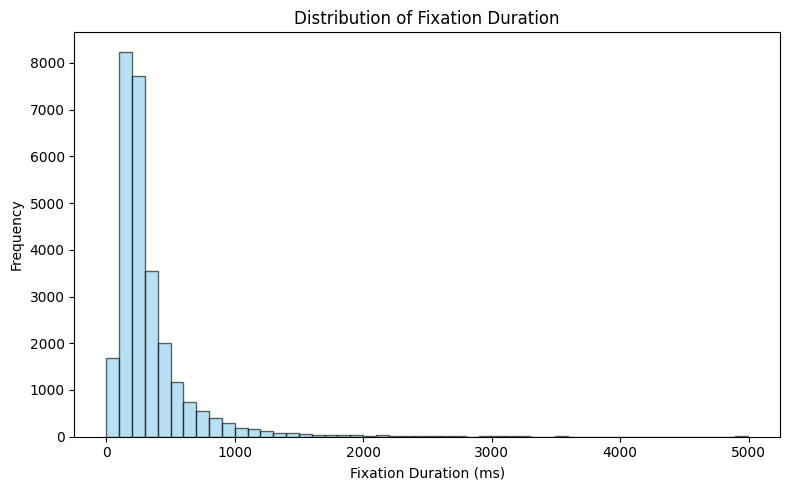

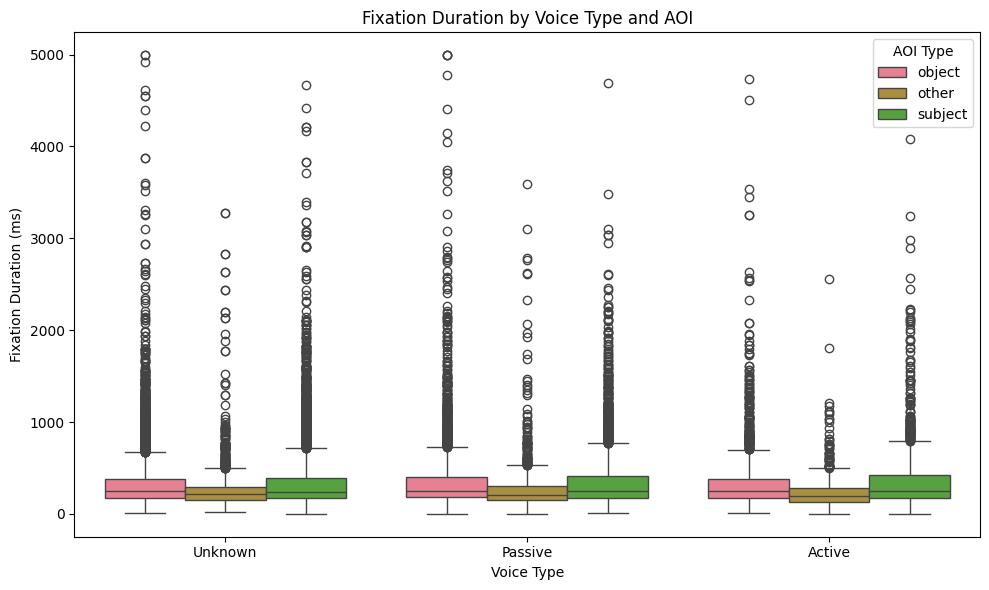

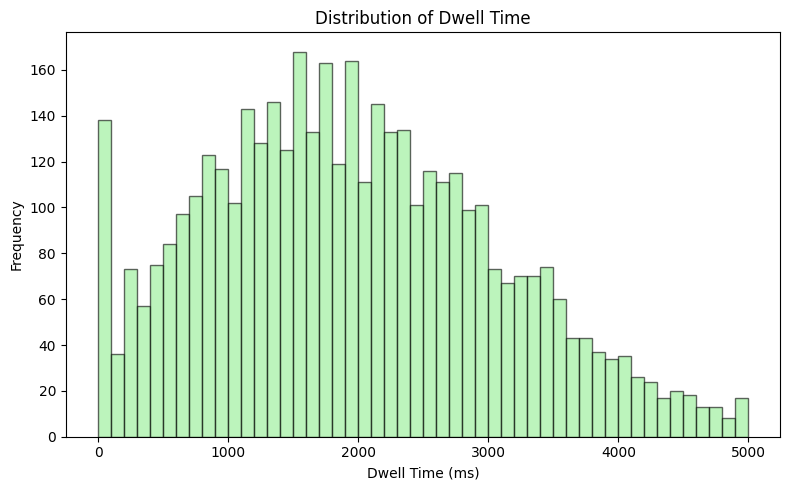

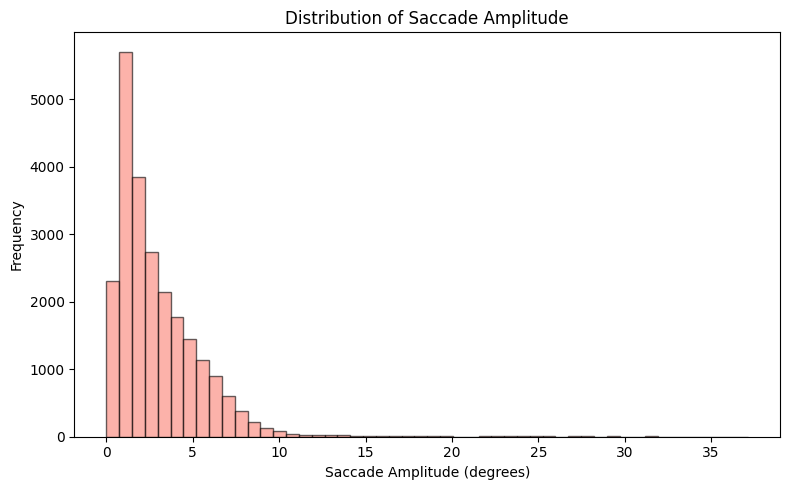

Creating AOI-specific summaries...
Calculating participant-level variability...

=== Exploratory Analysis Summary ===
Summary statistics saved to results/exploratory/
Plots saved to plots/exploratory/

Exploratory analysis complete!


/tmp/ipykernel_9524/3851273965.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aoi_summary = aoi_summary.groupby('voice_type').apply(


In [6]:
# %% Exploratory Data Analysis
# Script: 05_exploratory_analysis.py
# Purpose: Summary statistics and initial data exploration




# Set matplotlib style
plt.style.use('default')
sns.set_palette("husl")


# Filter out excluded data
fixation_clean = merged_fixation_data[~merged_fixation_data['exclude_fixation']].copy()
saccade_clean = merged_saccade_data[~merged_saccade_data['exclude_saccade']].copy()
trial_clean = merged_trial_data[~merged_trial_data['exclude_trial']].copy()

# %% Summary Statistics by Voice Type
print("Calculating summary statistics by voice type...")

# Note: voice_type may need to be extracted from voice_id or other variables
# For now, we'll use voice_id as a proxy if voice_type doesn't exist

def extract_vt_tmp(vid):
    vid_str = str(vid).upper()
    if 'ACT' in vid_str or 'ACTIVE' in vid_str: return 'Active'
    elif 'PNA' in vid_str or 'PWA' in vid_str or 'PASSIVE' in vid_str: return 'Passive'
    return 'Unknown'
for df_temp in [trial_clean, fixation_clean, saccade_clean]:
    if 'voice_id' in df_temp.columns:
        df_temp['voice_type'] = df_temp['voice_id'].apply(extract_vt_tmp)

# Fixation duration summary by voice type and AOI
fixation_summary = fixation_clean.groupby(['voice_type', 'aoi_type']).agg({
    'CURRENT_FIX_DURATION': ['count', 'mean', 'median', 'std', 'min', 'max']
}).reset_index()

fixation_summary.columns = ['voice_type', 'aoi_type', 'n', 'mean_duration', 
                            'median_duration', 'sd_duration', 'min_duration', 'max_duration']

fixation_summary.to_csv("results/exploratory/fixation_summary_by_voice_aoi.csv", index=False)

# Dwell time summary by voice type and AOI
dwell_time_summary = merged_interest_area_data[
    (merged_interest_area_data['IA_LABEL'] != "") & 
    merged_interest_area_data['IA_LABEL'].notna()
].groupby(['voice_id', 'aoi_type']).agg({
    'IA_DWELL_TIME': ['count', 'mean', 'median', 'std']
}).reset_index()

dwell_time_summary.columns = ['voice_id', 'aoi_type', 'n', 'mean_dwell_time', 
                              'median_dwell_time', 'sd_dwell_time']

dwell_time_summary.to_csv("results/exploratory/dwell_time_summary_by_voice_aoi.csv", index=False)

# Saccade summary by voice type
saccade_summary = saccade_clean.groupby('voice_type').agg({
    'CURRENT_SAC_AMPLITUDE': ['count', 'mean'],
    'CURRENT_SAC_DURATION': 'mean',
    'CURRENT_SAC_AVG_VELOCITY': 'mean'
}).reset_index()

saccade_summary.columns = ['voice_type', 'n', 'mean_amplitude', 'mean_duration', 'mean_velocity']

saccade_summary.to_csv("results/exploratory/saccade_summary_by_voice.csv", index=False)

# %% Distribution plots for key dependent variables
print("Creating distribution plots...")

# Fixation duration distribution
plt.figure(figsize=(8, 5))
plt.hist(fixation_clean['CURRENT_FIX_DURATION'], bins=50, color='skyblue', edgecolor='black', alpha=0.6)
plt.title("Distribution of Fixation Duration")
plt.xlabel("Fixation Duration (ms)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("plots/exploratory/fixation_duration_distribution.png", dpi=300)
plt.show()

# Fixation duration by voice type and AOI
fixation_clean_aoi = fixation_clean[fixation_clean['aoi_type'].notna()].copy()
if len(fixation_clean_aoi) > 0:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=fixation_clean_aoi, x='voice_type', y='CURRENT_FIX_DURATION', hue='aoi_type')
    plt.title("Fixation Duration by Voice Type and AOI")
    plt.xlabel("Voice Type")
    plt.ylabel("Fixation Duration (ms)")
    plt.legend(title="AOI Type")
    plt.tight_layout()
    plt.savefig("plots/exploratory/fixation_duration_by_voice_aoi.png", dpi=300)
    plt.show()

# Dwell time distribution
dwell_data = merged_interest_area_data[merged_interest_area_data['IA_DWELL_TIME'].notna()].copy()
if len(dwell_data) > 0:
    plt.figure(figsize=(8, 5))
    plt.hist(dwell_data['IA_DWELL_TIME'], bins=50, color='lightgreen', edgecolor='black', alpha=0.6)
    plt.title("Distribution of Dwell Time")
    plt.xlabel("Dwell Time (ms)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("plots/exploratory/dwell_time_distribution.png", dpi=300)
    plt.show()

# Saccade amplitude distribution
plt.figure(figsize=(8, 5))
plt.hist(saccade_clean['CURRENT_SAC_AMPLITUDE'], bins=50, color='salmon', edgecolor='black', alpha=0.6)
plt.title("Distribution of Saccade Amplitude")
plt.xlabel("Saccade Amplitude (degrees)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("plots/exploratory/saccade_amplitude_distribution.png", dpi=300)
plt.show()

# %% AOI-specific summaries
print("Creating AOI-specific summaries...")

aoi_summary = fixation_clean[fixation_clean['aoi_type'].notna()].groupby(['voice_type', 'aoi_type']).agg({
    'CURRENT_FIX_DURATION': ['count', 'sum', 'mean']
}).reset_index()

aoi_summary.columns = ['voice_type', 'aoi_type', 'total_fixations', 'total_duration', 'mean_duration']

# Calculate percentages
aoi_summary = aoi_summary.groupby('voice_type').apply(
    lambda x: x.assign(
        pct_fixations=100 * x['total_fixations'] / x['total_fixations'].sum(),
        pct_duration=100 * x['total_duration'] / x['total_duration'].sum()
    )
).reset_index(drop=True)

aoi_summary.to_csv("results/exploratory/aoi_summary.csv", index=False)

# %% Participant-level variability
print("Calculating participant-level variability...")

participant_variability = fixation_clean.groupby(['participant_id', 'voice_type', 'aoi_type']).agg({
    'CURRENT_FIX_DURATION': 'mean'
}).reset_index()

participant_variability.columns = ['participant_id', 'voice_type', 'aoi_type', 'mean_fixation_duration']

participant_variability = participant_variability.groupby(['voice_type', 'aoi_type']).agg({
    'mean_fixation_duration': ['count', 'mean', 'std']
}).reset_index()

participant_variability.columns = ['voice_type', 'aoi_type', 'n_participants', 
                                   'mean_across_participants', 'sd_across_participants']

participant_variability.to_csv("results/exploratory/participant_variability.csv", index=False)

# %% Print summary
print("\n=== Exploratory Analysis Summary ===")
print("Summary statistics saved to results/exploratory/")
print("Plots saved to plots/exploratory/")
print("\nExploratory analysis complete!")


## Step 6: Generate Analysis Report

Aggregates the results from the data quality checks and EDA to generate a readable text report, highlighting participant counts, outlier percentages, key findings, and recommendations.


In [7]:
# %% Generate Comprehensive Analysis Report
# Script: 06_generate_analysis_report.py
# Purpose: Analyze results and generate a comprehensive report




print("Generating comprehensive analysis report...")

# Load key result files
print("Loading analysis results...")

# Data quality report

# Load merged trial data for additional statistics

# Filter clean data
trial_clean = merged_trial_data[~merged_trial_data['exclude_trial']].copy()
fixation_clean = merged_fixation_data[~merged_fixation_data['exclude_fixation']].copy()
saccade_clean = merged_saccade_data[~merged_saccade_data['exclude_saccade']].copy()

# Generate report
report_lines = []

report_lines.append("=" * 80)
report_lines.append("EYE-TRACKING ANALYSIS REPORT")
report_lines.append("=" * 80)
report_lines.append(f"\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# 1. EXECUTIVE SUMMARY
report_lines.append("\n" + "=" * 80)
report_lines.append("1. EXECUTIVE SUMMARY")
report_lines.append("=" * 80 + "\n")

total_participants = len(participant_metadata)
total_trials = quality_report[quality_report['check'] == 'Total trials']['count'].values[0]
total_fixations = quality_report[quality_report['check'] == 'Total fixation records']['count'].values[0]
total_saccades = quality_report[quality_report['check'] == 'Total saccade records']['count'].values[0]

report_lines.append(f"This analysis examined eye-tracking data from {total_participants} participants.")
report_lines.append(f"Total trials analyzed: {total_trials:,}")
report_lines.append(f"Total fixations recorded: {total_fixations:,}")
report_lines.append(f"Total saccades recorded: {total_saccades:,}\n")

# Data completeness
participants_all_data = participant_metadata[
    (participant_metadata['has_fixation_data']) &
    (participant_metadata['has_interest_area_data']) &
    (participant_metadata['has_saccade_data'])
].shape[0]

report_lines.append(f"Participants with complete data (fixation, interest area, saccade): {participants_all_data}/{total_participants} ({100*participants_all_data/total_participants:.1f}%)")

# 2. DATA QUALITY ASSESSMENT
report_lines.append("\n" + "=" * 80)
report_lines.append("2. DATA QUALITY ASSESSMENT")
report_lines.append("=" * 80 + "\n")

for _, row in quality_report.iterrows():
    check = row['check']
    count = row['count']
    pct = row['percentage']
    
    if 'outlier' in check.lower() or 'impossible' in check.lower():
        report_lines.append(f"{check}: {count:,} ({pct:.2f}%)")
    elif 'missing' in check.lower():
        report_lines.append(f"{check}: {count:,} ({pct:.2f}%)")
    else:
        report_lines.append(f"{check}: {count:,}")

# Outlier summary
fixation_outliers = quality_report[quality_report['check'] == 'Fixation duration outliers']['count'].values[0]
fixation_outlier_pct = quality_report[quality_report['check'] == 'Fixation duration outliers']['percentage'].values[0]
saccade_outliers = quality_report[quality_report['check'] == 'Saccade amplitude outliers']['count'].values[0]
saccade_outlier_pct = quality_report[quality_report['check'] == 'Saccade amplitude outliers']['percentage'].values[0]

report_lines.append(f"\nOutlier Summary:")
report_lines.append(f"  - Fixation duration outliers: {fixation_outliers:,} ({fixation_outlier_pct:.2f}%)")
report_lines.append(f"  - Saccade amplitude outliers: {saccade_outliers:,} ({saccade_outlier_pct:.2f}%)")

if fixation_outlier_pct < 5 and saccade_outlier_pct < 5:
    report_lines.append("\nData quality assessment: GOOD - Outlier rates are within acceptable limits (<5%)")
else:
    report_lines.append("\nData quality assessment: CAUTION - Some outlier rates exceed 5%")

# 3. FIXATION ANALYSIS
report_lines.append("\n" + "=" * 80)
report_lines.append("3. FIXATION ANALYSIS")
report_lines.append("=" * 80 + "\n")

if 'mean_duration' in fixation_summary.columns:
    overall_mean_fix = fixation_clean['CURRENT_FIX_DURATION'].mean()
    overall_median_fix = fixation_clean['CURRENT_FIX_DURATION'].median()
    overall_std_fix = fixation_clean['CURRENT_FIX_DURATION'].std()
    
    report_lines.append(f"Overall Fixation Duration Statistics (ms):")
    report_lines.append(f"  Mean: {overall_mean_fix:.2f}")
    report_lines.append(f"  Median: {overall_median_fix:.2f}")
    report_lines.append(f"  Standard Deviation: {overall_std_fix:.2f}")
    report_lines.append(f"  Range: {fixation_clean['CURRENT_FIX_DURATION'].min():.2f} - {fixation_clean['CURRENT_FIX_DURATION'].max():.2f}\n")
    
    # By AOI type
    if 'aoi_type' in fixation_clean.columns:
        aoi_stats = fixation_clean.groupby('aoi_type')['CURRENT_FIX_DURATION'].agg(['mean', 'median', 'std', 'count']).round(2)
        report_lines.append("Fixation Duration by AOI Type:")
        for aoi, row in aoi_stats.iterrows():
            report_lines.append(f"  {aoi}:")
            report_lines.append(f"    Mean: {row['mean']:.2f} ms, Median: {row['median']:.2f} ms")
            report_lines.append(f"    SD: {row['std']:.2f} ms, Count: {int(row['count']):,}")

# 4. INTEREST AREA (AOI) ANALYSIS
report_lines.append("\n" + "=" * 80)
report_lines.append("4. INTEREST AREA (AOI) ANALYSIS")
report_lines.append("=" * 80 + "\n")

if not aoi_summary.empty:
    report_lines.append("AOI Summary Statistics:")
    report_lines.append(aoi_summary.to_string(index=False))
    
    # Calculate proportions
    if 'total_fixations' in aoi_summary.columns and 'voice_type' in aoi_summary.columns:
        for voice_type in aoi_summary['voice_type'].unique():
            voice_data = aoi_summary[aoi_summary['voice_type'] == voice_type]
            if 'pct_fixations' in voice_data.columns and 'pct_duration' in voice_data.columns:
                report_lines.append(f"\nVoice Type: {voice_type}")
                for _, row in voice_data.iterrows():
                    report_lines.append(f"  {row['aoi_type']}: {row['pct_fixations']:.1f}% of fixations, {row['pct_duration']:.1f}% of duration")

# 5. SACCADE ANALYSIS
report_lines.append("\n" + "=" * 80)
report_lines.append("5. SACCADE ANALYSIS")
report_lines.append("=" * 80 + "\n")

if 'CURRENT_SAC_AMPLITUDE' in saccade_clean.columns:
    overall_mean_amp = saccade_clean['CURRENT_SAC_AMPLITUDE'].mean()
    overall_mean_dur = saccade_clean['CURRENT_SAC_DURATION'].mean()
    overall_mean_vel = saccade_clean['CURRENT_SAC_AVG_VELOCITY'].mean()
    
    report_lines.append(f"Overall Saccade Statistics:")
    report_lines.append(f"  Mean Amplitude: {overall_mean_amp:.2f} degrees")
    report_lines.append(f"  Mean Duration: {overall_mean_dur:.2f} ms")
    report_lines.append(f"  Mean Velocity: {overall_mean_vel:.2f} deg/s\n")
    
    if not saccade_summary.empty and 'mean_amplitude' in saccade_summary.columns:
        report_lines.append("Saccade Statistics by Voice Type:")
        report_lines.append(saccade_summary.to_string(index=False))

# 6. PARTICIPANT VARIABILITY
report_lines.append("\n" + "=" * 80)
report_lines.append("6. PARTICIPANT VARIABILITY")
report_lines.append("=" * 80 + "\n")

if not participant_variability.empty and 'sd_across_participants' in participant_variability.columns:
    report_lines.append("Variability in Fixation Duration Across Participants:")
    report_lines.append(participant_variability.to_string(index=False))
    
    # Calculate coefficient of variation
    if 'mean_across_participants' in participant_variability.columns:
        participant_variability['cv'] = (participant_variability['sd_across_participants'] / 
                                        participant_variability['mean_across_participants'] * 100)
        report_lines.append("\nCoefficient of Variation (CV = SD/Mean * 100):")
        for _, row in participant_variability.iterrows():
            report_lines.append(f"  {row['voice_type']} - {row['aoi_type']}: {row['cv']:.1f}%")

# 7. KEY FINDINGS
report_lines.append("\n" + "=" * 80)
report_lines.append("7. KEY FINDINGS")
report_lines.append("=" * 80 + "\n")

findings = []

# Data quality findings
if fixation_outlier_pct < 5:
    findings.append(f"Data quality is good with only {fixation_outlier_pct:.2f}% fixation outliers")
else:
    findings.append(f"Data quality needs attention: {fixation_outlier_pct:.2f}% fixation outliers detected")

if saccade_outlier_pct < 5:
    findings.append(f"Saccade data quality is acceptable with {saccade_outlier_pct:.2f}% outliers")
else:
    findings.append(f"Saccade data quality needs review: {saccade_outlier_pct:.2f}% outliers detected")

# Missing voice_id
missing_voice_pct = quality_report[quality_report['check'] == 'Trials with missing voice_id']['percentage'].values[0]
if missing_voice_pct > 50:
    findings.append(f"High rate of missing voice_id: {missing_voice_pct:.1f}% of trials")
    findings.append("  Recommendation: Investigate voice_id encoding in source data")

# Fixation patterns
if 'aoi_type' in fixation_clean.columns:
    aoi_counts = fixation_clean['aoi_type'].value_counts()
    if len(aoi_counts) > 0:
        dominant_aoi = aoi_counts.index[0]
        dominant_pct = 100 * aoi_counts.iloc[0] / len(fixation_clean)
        findings.append(f"Dominant AOI type: {dominant_aoi} ({dominant_pct:.1f}% of fixations)")

for i, finding in enumerate(findings, 1):
    report_lines.append(f"{i}. {finding}")

# 8. RECOMMENDATIONS
report_lines.append("\n" + "=" * 80)
report_lines.append("8. RECOMMENDATIONS")
report_lines.append("=" * 80 + "\n")

recommendations = []

if missing_voice_pct > 30:
    recommendations.append("Investigate and fix voice_id encoding - over 30% of trials are missing this critical variable")

if fixation_outlier_pct > 3:
    recommendations.append("Review fixation duration outliers and consider excluding extreme values (>3 SD from mean)")

if saccade_outlier_pct > 1:
    recommendations.append("Review saccade amplitude outliers for potential data collection issues")

if participants_all_data < total_participants * 0.9:
    recommendations.append("Some participants have incomplete data - consider investigating missing data sources")

recommendations.append("Proceed with statistical modeling (GAMM) to examine voice type effects on eye-tracking measures")
recommendations.append("Consider including participant-level random effects in models to account for individual differences")

if not recommendations:
    recommendations.append("Data quality is sufficient for advanced statistical analysis")

for i, rec in enumerate(recommendations, 1):
    report_lines.append(f"{i}. {rec}")

# 9. DATA SUMMARY TABLE
report_lines.append("\n" + "=" * 80)
report_lines.append("9. DATA SUMMARY TABLE")
report_lines.append("=" * 80 + "\n")

summary_table = pd.DataFrame({
    'Metric': [
        'Total Participants',
        'Participants with Complete Data',
        'Total Trials',
        'Total Fixations',
        'Total Saccades',
        'Fixation Outliers (%)',
        'Saccade Outliers (%)',
        'Trials with Missing Voice ID (%)',
        'Mean Fixation Duration (ms)',
        'Mean Saccade Amplitude (deg)'
    ],
    'Value': [
        total_participants,
        participants_all_data,
        total_trials,
        total_fixations,
        total_saccades,
        f"{fixation_outlier_pct:.2f}%",
        f"{saccade_outlier_pct:.2f}%",
        f"{missing_voice_pct:.1f}%",
        f"{fixation_clean['CURRENT_FIX_DURATION'].mean():.2f}" if 'CURRENT_FIX_DURATION' in fixation_clean.columns else "N/A",
        f"{saccade_clean['CURRENT_SAC_AMPLITUDE'].mean():.2f}" if 'CURRENT_SAC_AMPLITUDE' in saccade_clean.columns else "N/A"
    ]
})

report_lines.append(summary_table.to_string(index=False))

# Write report to file
report_text = "\n".join(report_lines)

report_file = "results/reports/comprehensive_analysis_report.txt"
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(f"\nReport saved to: {report_file}")

# Also save summary table as CSV
summary_table.to_csv("results/reports/data_summary_table.csv", index=False)
print(f"Summary table saved to: results/reports/data_summary_table.csv")

# Save key findings
key_findings_df = pd.DataFrame({
    'finding_number': range(1, len(findings) + 1),
    'finding': findings
})
key_findings_df.to_csv("results/reports/key_findings.csv", index=False)
print(f"Key findings saved to: results/reports/key_findings.csv")

# Save recommendations
recommendations_df = pd.DataFrame({
    'recommendation_number': range(1, len(recommendations) + 1),
    'recommendation': recommendations
})
recommendations_df.to_csv("results/reports/recommendations.csv", index=False)
print(f"Recommendations saved to: results/reports/recommendations.csv")

print("\n" + "=" * 80)
print("Analysis Report Generation Complete!")
print("=" * 80)
print("\nGenerated files:")
print("  - results/reports/comprehensive_analysis_report.txt")
print("  - results/reports/data_summary_table.csv")
print("  - results/reports/key_findings.csv")
print("  - results/reports/recommendations.csv")


Generating comprehensive analysis report...
Loading analysis results...

Report saved to: results/reports/comprehensive_analysis_report.txt
Summary table saved to: results/reports/data_summary_table.csv
Key findings saved to: results/reports/key_findings.csv
Recommendations saved to: results/reports/recommendations.csv

Analysis Report Generation Complete!

Generated files:
  - results/reports/comprehensive_analysis_report.txt
  - results/reports/data_summary_table.csv
  - results/reports/key_findings.csv
  - results/reports/recommendations.csv


## Step 7: Compare Free Viewing vs. Voice Conditions

Statistically compares the 'Free Viewing' baseline against the 'Voice' condition using non-parametric tests (Mann-Whitney U) on fixation durations, dwell times, and saccade metrics.


Comparing Free Viewing (Baseline) vs Voice Conditions...
Creating condition labels...

Found 3 unique voice IDs in voice condition
Free viewing trials: 0
Voice trials: 900

1. FIXATION DURATION COMPARISON

Fixation Duration by Condition and AOI Type:
   condition aoi_type    n   mean  median    std    q25   q75
Free Viewing   object 7140 333.39   246.0 323.52 178.00 376.0
Free Viewing    other 1993 262.73   218.0 254.37 152.00 292.0
Free Viewing  subject 6088 349.89   240.0 351.52 168.75 388.0
       Voice   object 5706 356.00   251.0 371.85 180.00 396.0
       Voice    other 1655 262.98   202.0 276.65 142.00 295.5
       Voice  subject 4789 360.87   252.0 345.05 174.00 416.0

Statistical Tests (Free Viewing vs Voice):

AOI: object
  Free Viewing: M=333.39, SD=323.52, n=7140
  Voice: M=356.00, SD=371.85, n=5706
  Difference: 22.61 ms (6.8%)
  Mann-Whitney U: 19791916.50, p=0.0056
  Cohen's d: 0.065
  Significance: ** p < 0.01

AOI: other
  Free Viewing: M=262.73, SD=254.37, n=1993
  Vo

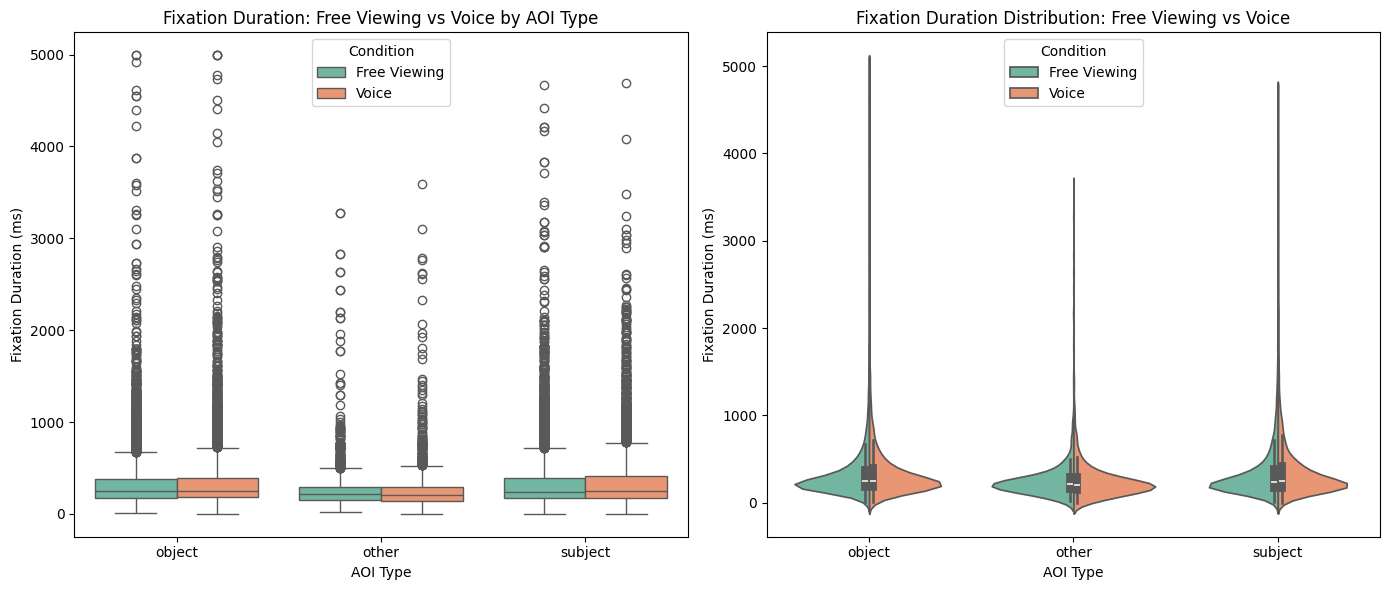

Saved: plots/comparisons/fixation_duration_comparison.png


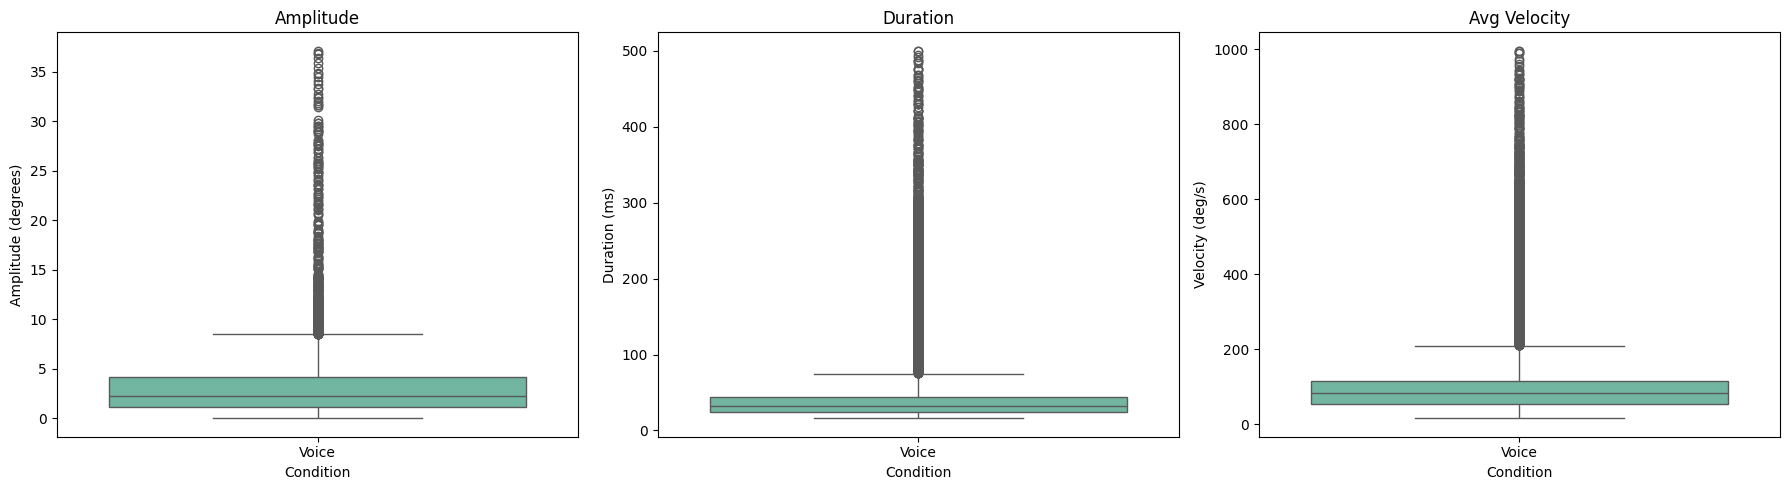

Saved: plots/comparisons/saccade_comparison.png

5. GENERATING SUMMARY REPORT

COMPARISON ANALYSIS COMPLETE!

Generated files:
  - results/comparisons/fixation_duration_comparison.csv
  - results/comparisons/fixation_statistical_comparison.csv
  - results/comparisons/saccade_comparison.csv
  - results/comparisons/saccade_statistical_comparison.csv
  - results/comparisons/free_viewing_vs_voice_summary.txt
  - plots/comparisons/fixation_duration_comparison.png
  - plots/comparisons/saccade_comparison.png


In [8]:
# %% Compare Free Viewing vs Voice Conditions
# Script: 07_compare_free_viewing_vs_voice.py
# Purpose: Compare free viewing (baseline) data with voice conditions




print("Comparing Free Viewing (Baseline) vs Voice Conditions...")


# Filter clean data
fixation_clean = merged_fixation_data[~merged_fixation_data['exclude_fixation']].copy()
trial_clean = merged_trial_data[~merged_trial_data['exclude_trial']].copy()
saccade_clean = merged_saccade_data[~merged_saccade_data['exclude_saccade']].copy()

# Create condition variable: Free Viewing vs Voice
print("Creating condition labels...")

def create_condition(row):
    """Create condition label: Free Viewing (baseline) or Voice."""
    if pd.isna(row.get('voice_id')) or row.get('voice_id') == "" or row.get('voice_id') == "UNDEFINEDnull":
        return "Free Viewing"
    else:
        return "Voice"

# Apply to all datasets
fixation_clean['condition'] = fixation_clean.apply(create_condition, axis=1)
trial_clean['condition'] = trial_clean.apply(create_condition, axis=1)
saccade_clean['condition'] = saccade_clean.apply(create_condition, axis=1)

# Get unique voice_id values for voice condition
voice_ids = fixation_clean[fixation_clean['condition'] == 'Voice']['voice_id'].dropna().unique()
print(f"\nFound {len(voice_ids)} unique voice IDs in voice condition")
print(f"Free viewing trials: {len(trial_clean[trial_clean['condition'] == 'Free Viewing'])}")
print(f"Voice trials: {len(trial_clean[trial_clean['condition'] == 'Voice'])}")

# 1. FIXATION DURATION COMPARISON
print("\n" + "="*80)
print("1. FIXATION DURATION COMPARISON")
print("="*80)

fixation_comparison = fixation_clean.groupby(['condition', 'aoi_type'])['CURRENT_FIX_DURATION'].agg([
    'count', 'mean', 'median', 'std', 
    lambda x: np.percentile(x, 25), 
    lambda x: np.percentile(x, 75)
]).round(2)

fixation_comparison.columns = ['n', 'mean', 'median', 'std', 'q25', 'q75']
fixation_comparison = fixation_comparison.reset_index()

print("\nFixation Duration by Condition and AOI Type:")
print(fixation_comparison.to_string(index=False))

# Save comparison
fixation_comparison.to_csv("results/comparisons/fixation_duration_comparison.csv", index=False)

# Statistical tests
print("\nStatistical Tests (Free Viewing vs Voice):")

comparison_results = []

for aoi in fixation_clean['aoi_type'].dropna().unique():
    free_viewing = fixation_clean[
        (fixation_clean['condition'] == 'Free Viewing') & 
        (fixation_clean['aoi_type'] == aoi)
    ]['CURRENT_FIX_DURATION'].dropna()
    
    voice = fixation_clean[
        (fixation_clean['condition'] == 'Voice') & 
        (fixation_clean['aoi_type'] == aoi)
    ]['CURRENT_FIX_DURATION'].dropna()
    
    if len(free_viewing) > 0 and len(voice) > 0:
        # Mann-Whitney U test (non-parametric)
        statistic, p_value = stats.mannwhitneyu(free_viewing, voice, alternative='two-sided')
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt((free_viewing.std()**2 + voice.std()**2) / 2)
        cohens_d = (voice.mean() - free_viewing.mean()) / pooled_std if pooled_std > 0 else 0
        
        comparison_results.append({
            'aoi_type': aoi,
            'free_viewing_mean': free_viewing.mean(),
            'voice_mean': voice.mean(),
            'difference': voice.mean() - free_viewing.mean(),
            'percent_change': ((voice.mean() - free_viewing.mean()) / free_viewing.mean() * 100) if free_viewing.mean() > 0 else 0,
            'mannwhitney_u': statistic,
            'p_value': p_value,
            'cohens_d': cohens_d,
            'n_free_viewing': len(free_viewing),
            'n_voice': len(voice)
        })
        
        print(f"\nAOI: {aoi}")
        print(f"  Free Viewing: M={free_viewing.mean():.2f}, SD={free_viewing.std():.2f}, n={len(free_viewing)}")
        print(f"  Voice: M={voice.mean():.2f}, SD={voice.std():.2f}, n={len(voice)}")
        print(f"  Difference: {voice.mean() - free_viewing.mean():.2f} ms ({((voice.mean() - free_viewing.mean()) / free_viewing.mean() * 100):.1f}%)")
        print(f"  Mann-Whitney U: {statistic:.2f}, p={p_value:.4f}")
        print(f"  Cohen's d: {cohens_d:.3f}")
        if p_value < 0.001:
            print(f"  Significance: *** p < 0.001")
        elif p_value < 0.01:
            print(f"  Significance: ** p < 0.01")
        elif p_value < 0.05:
            print(f"  Significance: * p < 0.05")
        else:
            print(f"  Significance: ns (p >= 0.05)")

statistical_comparison = pd.DataFrame(comparison_results)
statistical_comparison.to_csv("results/comparisons/fixation_statistical_comparison.csv", index=False)

# 2. DWELL TIME COMPARISON (if available)
print("\n" + "="*80)
print("2. DWELL TIME COMPARISON")
print("="*80)

# Load interest area data if available
try:
    interest_area_clean = merged_interest_area_data[
        merged_interest_area_data['IA_DWELL_TIME'].notna() & 
        (merged_interest_area_data['IA_DWELL_TIME'] > 0)
    ].copy()
    
    interest_area_clean['condition'] = interest_area_clean.apply(create_condition, axis=1)
    
    dwell_time_comparison = interest_area_clean.groupby(['condition', 'aoi_type'])['IA_DWELL_TIME'].agg([
        'count', 'mean', 'median', 'std'
    ]).round(2)
    
    dwell_time_comparison.columns = ['n', 'mean', 'median', 'std']
    dwell_time_comparison = dwell_time_comparison.reset_index()
    
    print("\nDwell Time by Condition and AOI Type:")
    print(dwell_time_comparison.to_string(index=False))
    
    dwell_time_comparison.to_csv("results/comparisons/dwell_time_comparison.csv", index=False)
    
    # Statistical tests for dwell time
    dwell_time_results = []
    for aoi in interest_area_clean['aoi_type'].dropna().unique():
        free_viewing = interest_area_clean[
            (interest_area_clean['condition'] == 'Free Viewing') & 
            (interest_area_clean['aoi_type'] == aoi)
        ]['IA_DWELL_TIME'].dropna()
        
        voice = interest_area_clean[
            (interest_area_clean['condition'] == 'Voice') & 
            (interest_area_clean['aoi_type'] == aoi)
        ]['IA_DWELL_TIME'].dropna()
        
        if len(free_viewing) > 0 and len(voice) > 0:
            statistic, p_value = stats.mannwhitneyu(free_viewing, voice, alternative='two-sided')
            pooled_std = np.sqrt((free_viewing.std()**2 + voice.std()**2) / 2)
            cohens_d = (voice.mean() - free_viewing.mean()) / pooled_std if pooled_std > 0 else 0
            
            dwell_time_results.append({
                'aoi_type': aoi,
                'free_viewing_mean': free_viewing.mean(),
                'voice_mean': voice.mean(),
                'difference': voice.mean() - free_viewing.mean(),
                'percent_change': ((voice.mean() - free_viewing.mean()) / free_viewing.mean() * 100) if free_viewing.mean() > 0 else 0,
                'p_value': p_value,
                'cohens_d': cohens_d,
                'n_free_viewing': len(free_viewing),
                'n_voice': len(voice)
            })
    
    dwell_time_stats = pd.DataFrame(dwell_time_results)
    dwell_time_stats.to_csv("results/comparisons/dwell_time_statistical_comparison.csv", index=False)
    
except Exception as e:
    print(f"Could not load interest area data: {e}")

# 3. SACCADE COMPARISON
print("\n" + "="*80)
print("3. SACCADE COMPARISON")
print("="*80)

saccade_comparison = saccade_clean.groupby('condition').agg({
    'CURRENT_SAC_AMPLITUDE': ['count', 'mean', 'median', 'std'],
    'CURRENT_SAC_DURATION': ['mean', 'median', 'std'],
    'CURRENT_SAC_AVG_VELOCITY': ['mean', 'median', 'std']
}).round(2)

saccade_comparison.columns = ['_'.join(col).strip() for col in saccade_comparison.columns.values]
saccade_comparison = saccade_comparison.reset_index()

print("\nSaccade Metrics by Condition:")
print(saccade_comparison.to_string(index=False))

saccade_comparison.to_csv("results/comparisons/saccade_comparison.csv", index=False)

# Statistical tests for saccades
saccade_results = []

for metric in ['CURRENT_SAC_AMPLITUDE', 'CURRENT_SAC_DURATION', 'CURRENT_SAC_AVG_VELOCITY']:
    if metric in saccade_clean.columns:
        free_viewing = saccade_clean[
            saccade_clean['condition'] == 'Free Viewing'
        ][metric].dropna()
        
        voice = saccade_clean[
            saccade_clean['condition'] == 'Voice'
        ][metric].dropna()
        
        if len(free_viewing) > 0 and len(voice) > 0:
            statistic, p_value = stats.mannwhitneyu(free_viewing, voice, alternative='two-sided')
            pooled_std = np.sqrt((free_viewing.std()**2 + voice.std()**2) / 2)
            cohens_d = (voice.mean() - free_viewing.mean()) / pooled_std if pooled_std > 0 else 0
            
            saccade_results.append({
                'metric': metric,
                'free_viewing_mean': free_viewing.mean(),
                'voice_mean': voice.mean(),
                'difference': voice.mean() - free_viewing.mean(),
                'percent_change': ((voice.mean() - free_viewing.mean()) / free_viewing.mean() * 100) if free_viewing.mean() > 0 else 0,
                'p_value': p_value,
                'cohens_d': cohens_d,
                'n_free_viewing': len(free_viewing),
                'n_voice': len(voice)
            })

saccade_stats = pd.DataFrame(saccade_results)
saccade_stats.to_csv("results/comparisons/saccade_statistical_comparison.csv", index=False)

# 4. VISUALIZATIONS
print("\n" + "="*80)
print("4. CREATING VISUALIZATIONS")
print("="*80)

plt.style.use('default')
sns.set_palette("Set2")

# Fixation duration comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
fixation_plot_data = fixation_clean[fixation_clean['aoi_type'].notna()].copy()
sns.boxplot(data=fixation_plot_data, x='aoi_type', y='CURRENT_FIX_DURATION', 
            hue='condition', ax=axes[0])
axes[0].set_title('Fixation Duration: Free Viewing vs Voice by AOI Type')
axes[0].set_xlabel('AOI Type')
axes[0].set_ylabel('Fixation Duration (ms)')
axes[0].legend(title='Condition')

# Violin plot
sns.violinplot(data=fixation_plot_data, x='aoi_type', y='CURRENT_FIX_DURATION', 
               hue='condition', ax=axes[1], split=True)
axes[1].set_title('Fixation Duration Distribution: Free Viewing vs Voice')
axes[1].set_xlabel('AOI Type')
axes[1].set_ylabel('Fixation Duration (ms)')
axes[1].legend(title='Condition')

plt.tight_layout()
plt.savefig("plots/comparisons/fixation_duration_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/comparisons/fixation_duration_comparison.png")

# Saccade comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, metric in enumerate(['CURRENT_SAC_AMPLITUDE', 'CURRENT_SAC_DURATION', 'CURRENT_SAC_AVG_VELOCITY']):
    if metric in saccade_clean.columns:
        sns.boxplot(data=saccade_clean, x='condition', y=metric, ax=axes[idx])
        axes[idx].set_title(f'{metric.replace("CURRENT_SAC_", "").replace("_", " ").title()}')
        axes[idx].set_xlabel('Condition')
        if 'AMPLITUDE' in metric:
            axes[idx].set_ylabel('Amplitude (degrees)')
        elif 'DURATION' in metric:
            axes[idx].set_ylabel('Duration (ms)')
        else:
            axes[idx].set_ylabel('Velocity (deg/s)')

plt.tight_layout()
plt.savefig("plots/comparisons/saccade_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/comparisons/saccade_comparison.png")

# 5. SUMMARY REPORT
print("\n" + "="*80)
print("5. GENERATING SUMMARY REPORT")
print("="*80)

summary_lines = []
summary_lines.append("="*80)
summary_lines.append("FREE VIEWING (BASELINE) vs VOICE CONDITION COMPARISON")
summary_lines.append("="*80)
summary_lines.append(f"\nGenerated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

summary_lines.append("CONDITION SUMMARY:")
summary_lines.append(f"  Free Viewing (Baseline) trials: {len(trial_clean[trial_clean['condition'] == 'Free Viewing'])}")
summary_lines.append(f"  Voice trials: {len(trial_clean[trial_clean['condition'] == 'Voice'])}")
summary_lines.append(f"  Free Viewing fixations: {len(fixation_clean[fixation_clean['condition'] == 'Free Viewing'])}")
summary_lines.append(f"  Voice fixations: {len(fixation_clean[fixation_clean['condition'] == 'Voice'])}")

summary_lines.append("\n" + "="*80)
summary_lines.append("KEY FINDINGS")
summary_lines.append("="*80 + "\n")

if not statistical_comparison.empty:
    summary_lines.append("Fixation Duration Comparisons:")
    for _, row in statistical_comparison.iterrows():
        direction = "longer" if row['difference'] > 0 else "shorter"
        sig = ""
        if row['p_value'] < 0.001:
            sig = "***"
        elif row['p_value'] < 0.01:
            sig = "**"
        elif row['p_value'] < 0.05:
            sig = "*"
        
        summary_lines.append(
            f"  {row['aoi_type']} AOI: Voice condition shows {abs(row['percent_change']):.1f}% "
            f"{direction} fixations ({row['difference']:.1f} ms) {sig}"
        )
        summary_lines.append(f"    Effect size (Cohen's d): {row['cohens_d']:.3f}")

if not saccade_stats.empty:
    summary_lines.append("\nSaccade Comparisons:")
    for _, row in saccade_stats.iterrows():
        metric_name = row['metric'].replace('CURRENT_SAC_', '').replace('_', ' ').title()
        direction = "higher" if row['difference'] > 0 else "lower"
        sig = ""
        if row['p_value'] < 0.001:
            sig = "***"
        elif row['p_value'] < 0.01:
            sig = "**"
        elif row['p_value'] < 0.05:
            sig = "*"
        
        summary_lines.append(
            f"  {metric_name}: Voice condition shows {abs(row['percent_change']):.1f}% "
            f"{direction} values {sig}"
        )

summary_text = "\n".join(summary_lines)

with open("results/comparisons/free_viewing_vs_voice_summary.txt", 'w', encoding='utf-8') as f:
    f.write(summary_text)

print("\n" + "="*80)
print("COMPARISON ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated files:")
print("  - results/comparisons/fixation_duration_comparison.csv")
print("  - results/comparisons/fixation_statistical_comparison.csv")
print("  - results/comparisons/saccade_comparison.csv")
print("  - results/comparisons/saccade_statistical_comparison.csv")
print("  - results/comparisons/free_viewing_vs_voice_summary.txt")
print("  - plots/comparisons/fixation_duration_comparison.png")
print("  - plots/comparisons/saccade_comparison.png")


## Step 8: First Fixation Location Bias

Analyzes spatial biases by looking at the very first fixation on an image per trial. It calculates the distance from the screen center and evaluates quadrant center bias.


Analyzing First Fixation Locations on Images...

Total fixations: 27371
Columns available: ['participant_id', 'data_file', 'TRIAL_INDEX', 'TRIAL_LABEL', 'TRIAL_START_TIME', 'CURRENT_FIX_DURATION', 'CURRENT_FIX_INDEX', 'CURRENT_FIX_START', 'CURRENT_FIX_END', 'CURRENT_FIX_X', 'CURRENT_FIX_Y', 'CURRENT_FIX_INTEREST_AREA_LABEL', 'CURRENT_FIX_INTEREST_AREA_ID', 'CURRENT_FIX_INTEREST_AREA_INDEX', 'CURRENT_FIX_INTEREST_AREA_DWELL_TIME', 'CURRENT_FIX_INTEREST_AREA_FIX_COUNT', 'TRIAL_FIXATION_TOTAL', 'sentence', 'voice_id', 'image_id', 'stim_id', 'image', 'stimulus_file', 'session_var', 'exp_id', 'language', 'audio', 'voice_type_category', 'aoi_type', 'trial_id', 'time_from_trial_start', 'time_window', 'trial_duration_x', 'sentence_clean', 'merge_key', 'total_trial_duration', 'trial_duration_y', 'n_saccades', 'mean_saccade_amplitude', 'exclude_fixation']

Grouping by: ['participant_id', 'TRIAL_INDEX', 'image_id']
Fixations with valid coordinates: 27371

Identifying first fixations per trial...


/tmp/ipykernel_9524/924298600.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_fixations = fixation_clean.groupby(grouping_cols).apply(


Total first fixations identified: 1848

1. FIRST FIXATION LOCATIONS BY IMAGE

Found 18 unique images

Summary Statistics by Image:
image_id  n_trials  x_mean  x_median  x_std  x_min  x_max  y_mean  y_median  y_std  y_min  y_max
  IMG_01       103  947.00    955.30  76.44  401.1 1337.0  520.34    532.10  71.98  150.1  706.6
  IMG_02       102  956.09    954.55  69.88  711.0 1229.3  531.96    528.80  75.84  415.3 1180.1
  IMG_03       103  955.81    954.80  53.55  726.0 1269.9  531.11    532.90  67.02  159.0  809.2
  IMG_04       103  946.18    952.70  59.72  655.9 1201.1  523.21    530.30  59.08  244.7  704.7
  IMG_05       102  953.11    958.05  37.73  771.0 1119.7  523.13    536.00  62.38  148.5  651.6
  IMG_06       103  954.59    957.90 100.67  147.1 1330.3  538.45    533.50 115.74   50.7 1275.3
  IMG_07       101  945.51    956.00  57.52  632.0 1059.3  522.97    533.80  67.79  189.9  799.3
  IMG_08       103  952.41    954.90  39.52  823.0 1128.6  525.56    531.20  50.56  252.6  64

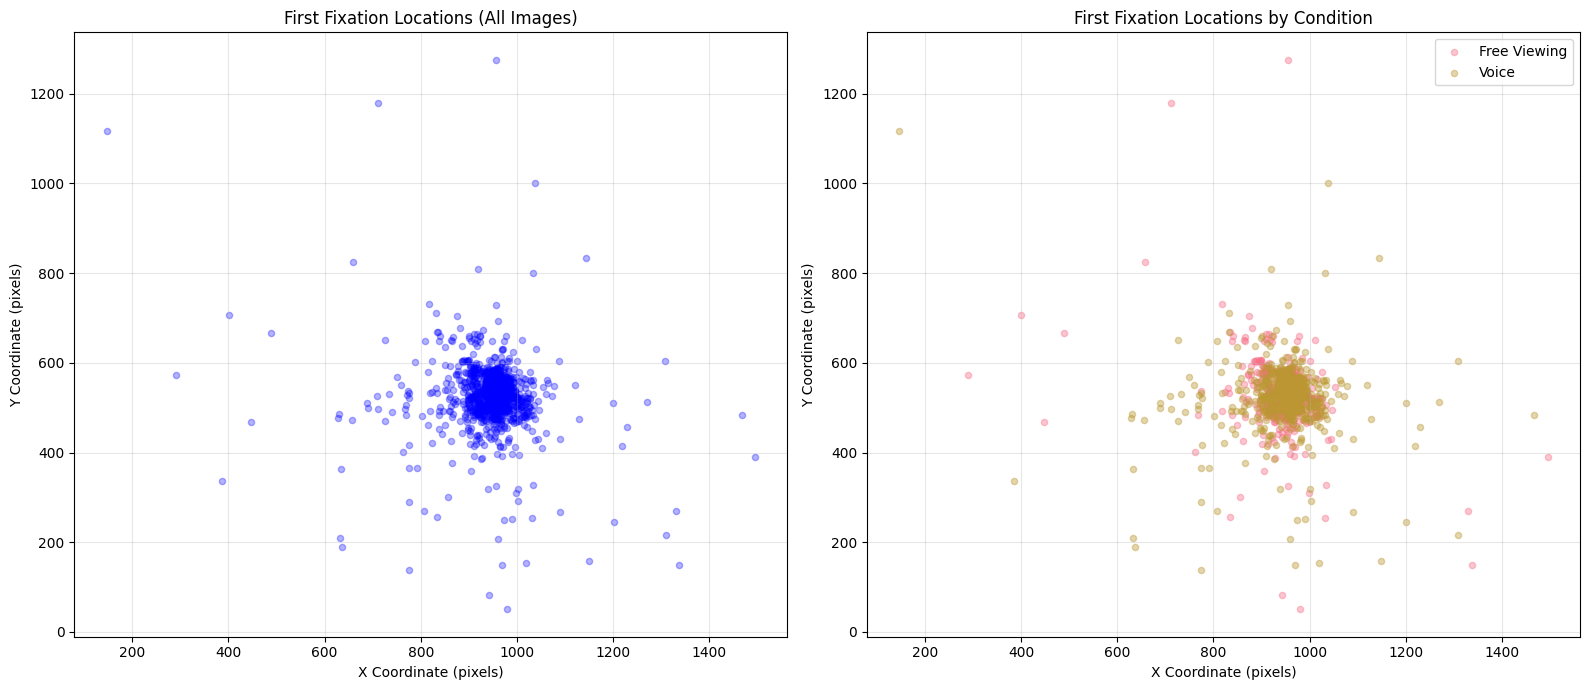

Saved: plots/first_fixation/first_fixation_locations_scatter.png


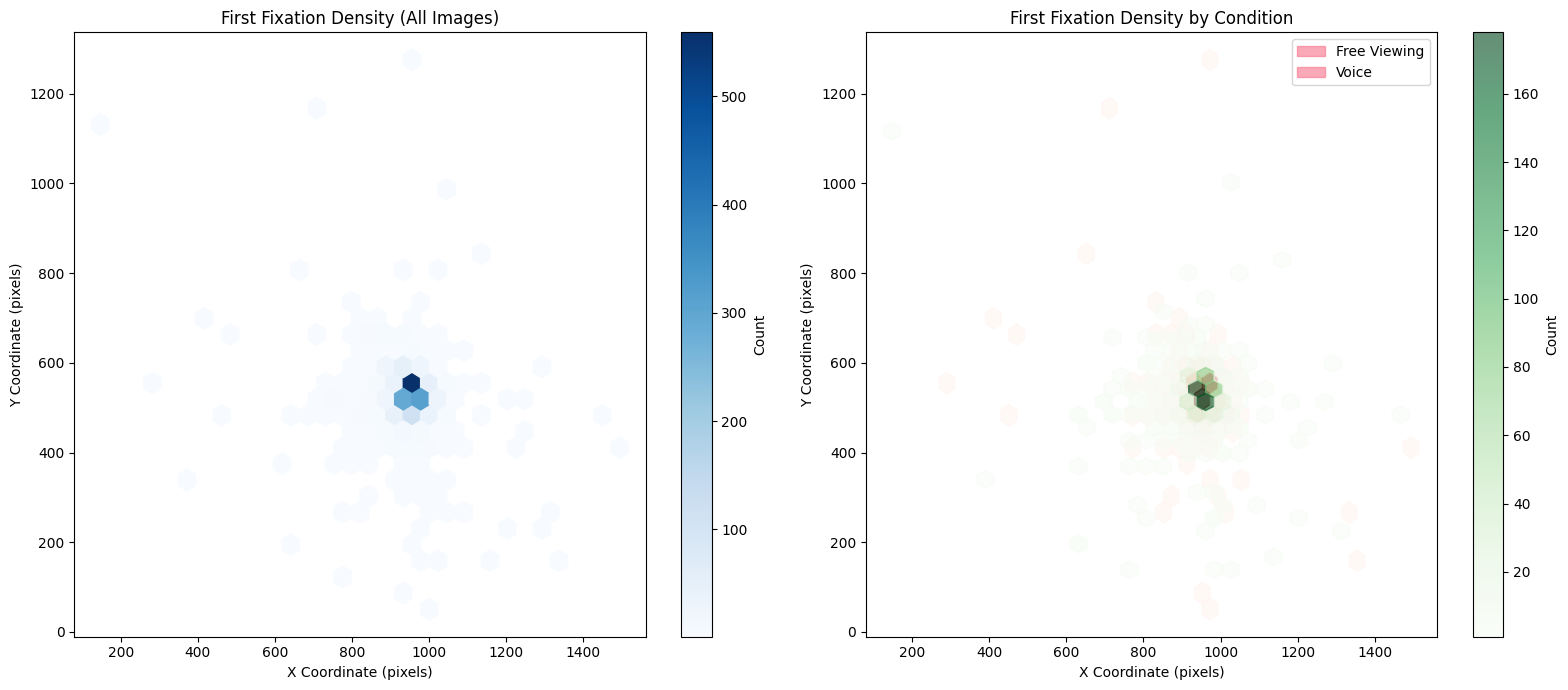

Saved: plots/first_fixation/first_fixation_density.png


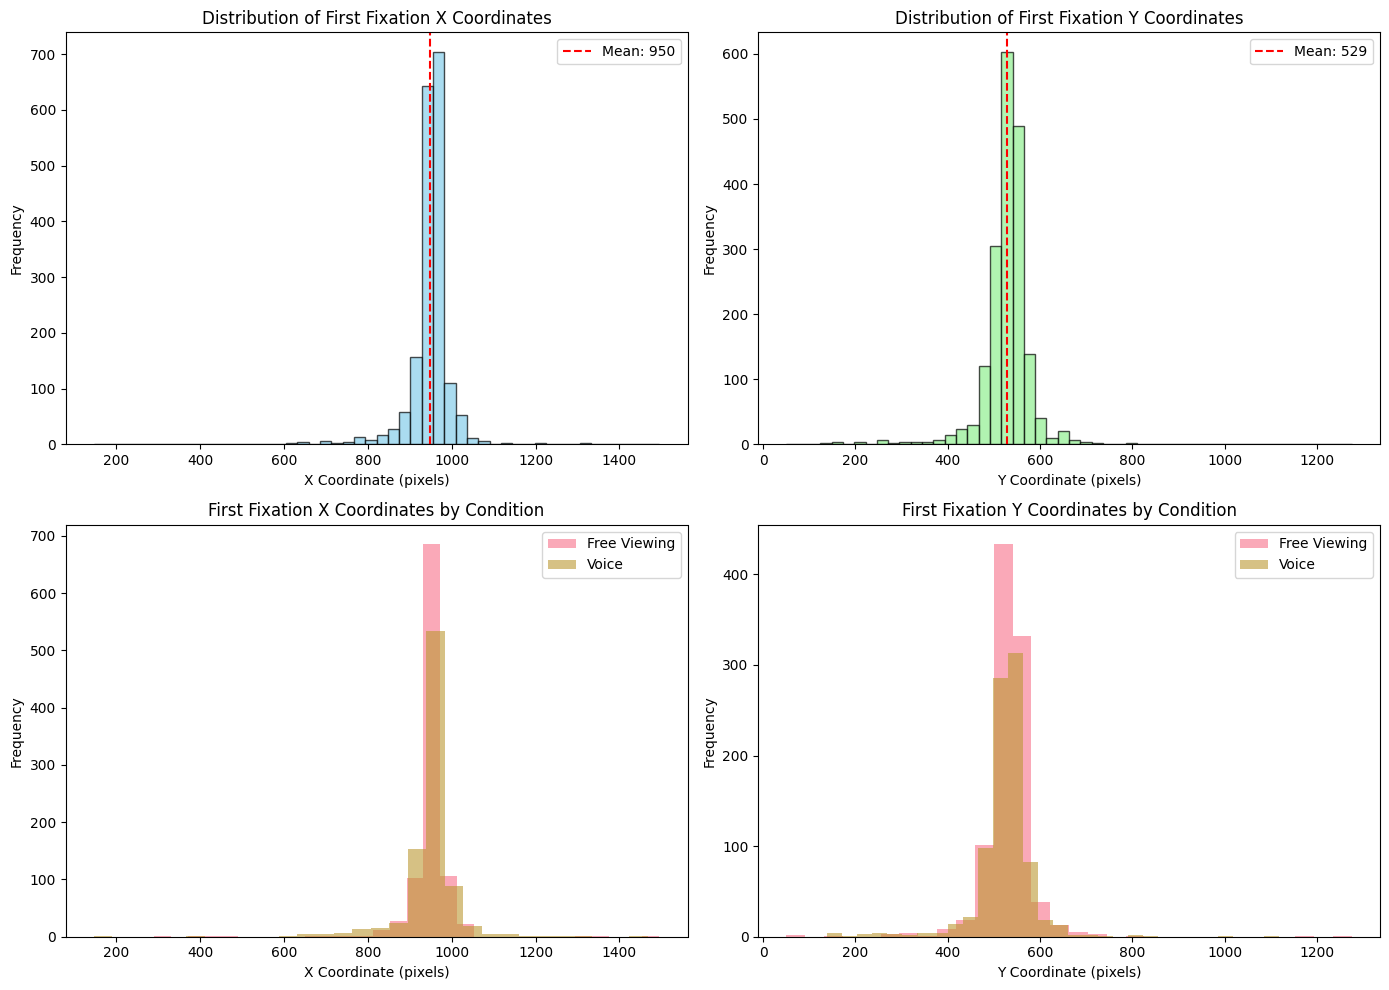

Saved: plots/first_fixation/first_fixation_distributions.png


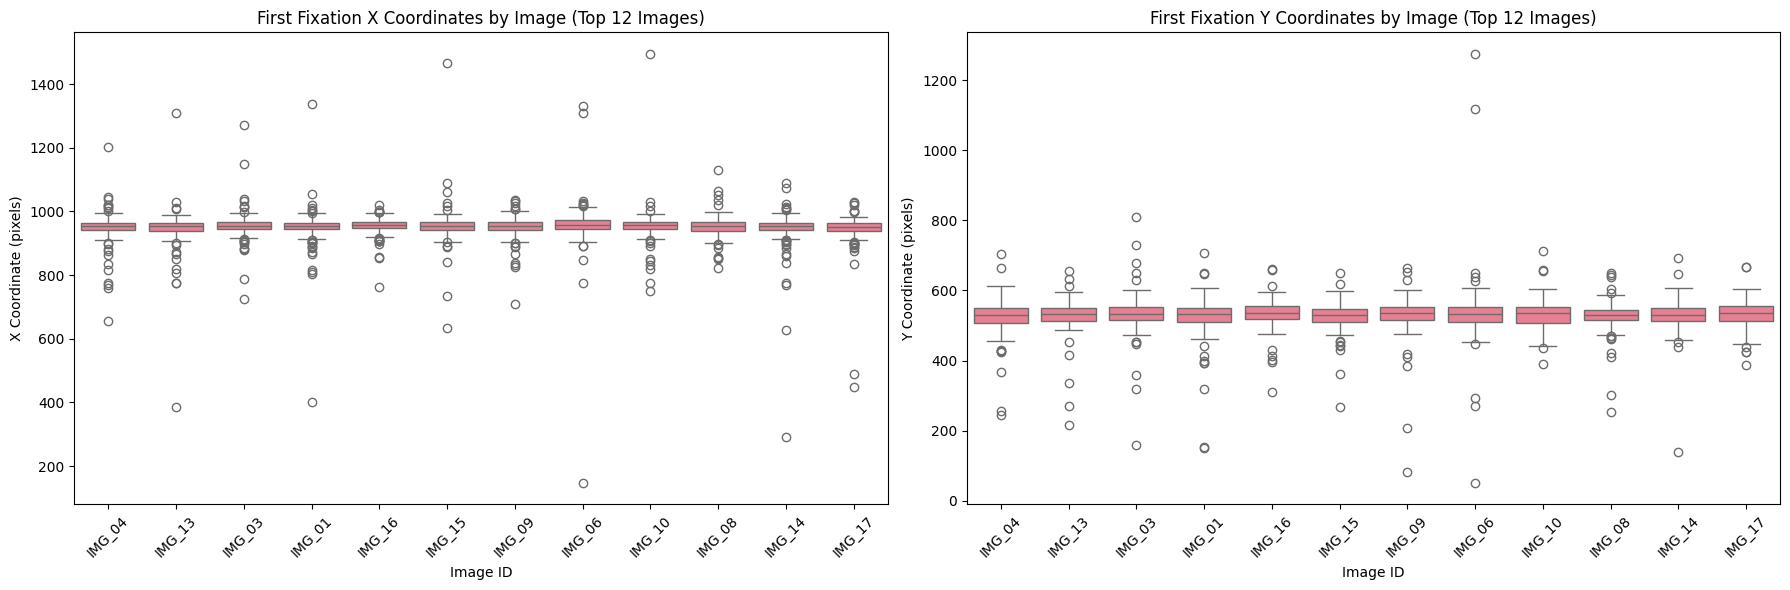

Saved: plots/first_fixation/first_fixation_by_image_boxplot.png

5. CENTER BIAS ANALYSIS
Estimated screen center: X=955, Y=532

Distance from Center by Condition:
             distance_from_center              
                             mean median    std
condition                                      
Free Viewing                42.27  23.99  68.68
Voice                       57.38  32.95  79.83

6. QUADRANT ANALYSIS

First Fixation Quadrant Distribution:
   condition     quadrant  count  percentage
Free Viewing  Bottom-Left    246       25.47
Free Viewing Bottom-Right    264       27.33
Free Viewing     Top-Left    228       23.60
Free Viewing    Top-Right    228       23.60
       Voice  Bottom-Left    224       25.40
       Voice Bottom-Right    189       21.43
       Voice     Top-Left    226       25.62
       Voice    Top-Right    243       27.55

7. GENERATING REPORT

FIRST FIXATION LOCATION ANALYSIS COMPLETE!

Generated files:
  - results/first_fixation/first_fixation_by_im

In [9]:
# %% First Fixation Location Analysis
# Script: 08_first_fixation_location.py
# Purpose: Analyze the location of first fixations on images




print("Analyzing First Fixation Locations on Images...")


# Filter clean data (no exclusions for this analysis, or use clean data)
fixation_clean = merged_fixation_data[~merged_fixation_data['exclude_fixation']].copy()

# Check if we have image_id and X/Y coordinates
print(f"\nTotal fixations: {len(fixation_clean)}")
print(f"Columns available: {fixation_clean.columns.tolist()}")

# Ensure we have required columns
required_cols = ['CURRENT_FIX_X', 'CURRENT_FIX_Y', 'CURRENT_FIX_START', 'participant_id', 'TRIAL_INDEX']
if not all(col in fixation_clean.columns for col in required_cols):
    print("Warning: Missing required columns. Checking fixation_data...")
    fixation_clean = fixation_data.copy()
    required_cols = ['CURRENT_FIX_X', 'CURRENT_FIX_Y', 'CURRENT_FIX_START', 'participant_id', 'TRIAL_INDEX']

# Get image_id if available, otherwise use trial identifier
if 'image_id' in fixation_clean.columns:
    grouping_cols = ['participant_id', 'TRIAL_INDEX', 'image_id']
    use_image_id = True
elif 'stim_id' in fixation_clean.columns:
    grouping_cols = ['participant_id', 'TRIAL_INDEX', 'stim_id']
    use_image_id = True
    fixation_clean['image_id'] = fixation_clean['stim_id']
else:
    grouping_cols = ['participant_id', 'TRIAL_INDEX']
    use_image_id = False
    fixation_clean['image_id'] = fixation_clean['participant_id'].astype(str) + '_' + fixation_clean['TRIAL_INDEX'].astype(str)

print(f"\nGrouping by: {grouping_cols}")

# Filter out missing coordinates
fixation_clean = fixation_clean[
    fixation_clean['CURRENT_FIX_X'].notna() & 
    fixation_clean['CURRENT_FIX_Y'].notna() &
    (fixation_clean['CURRENT_FIX_X'] >= 0) &
    (fixation_clean['CURRENT_FIX_Y'] >= 0)
].copy()

print(f"Fixations with valid coordinates: {len(fixation_clean)}")

# Identify first fixation for each trial
print("\nIdentifying first fixations per trial...")

first_fixations = fixation_clean.groupby(grouping_cols).apply(
    lambda x: x.loc[x['CURRENT_FIX_START'].idxmin()]
).reset_index(drop=True)

print(f"Total first fixations identified: {len(first_fixations)}")

# Create condition label (Free Viewing vs Voice)
def create_condition(row):
    """Create condition label."""
    if 'voice_id' in row:
        if pd.isna(row.get('voice_id')) or row.get('voice_id') == "" or row.get('voice_id') == "UNDEFINEDnull":
            return "Free Viewing"
        else:
            return "Voice"
    return "Unknown"

first_fixations['condition'] = first_fixations.apply(create_condition, axis=1)

# 1. SUMMARY STATISTICS BY IMAGE
print("\n" + "="*80)
print("1. FIRST FIXATION LOCATIONS BY IMAGE")
print("="*80)

image_summary = first_fixations.groupby('image_id').agg({
    'CURRENT_FIX_X': ['count', 'mean', 'median', 'std', 'min', 'max'],
    'CURRENT_FIX_Y': ['mean', 'median', 'std', 'min', 'max']
}).round(2)

image_summary.columns = ['_'.join(col).strip() for col in image_summary.columns.values]
image_summary = image_summary.reset_index()
image_summary.columns = ['image_id', 'n_trials', 'x_mean', 'x_median', 'x_std', 'x_min', 'x_max',
                         'y_mean', 'y_median', 'y_std', 'y_min', 'y_max']

print(f"\nFound {len(image_summary)} unique images")
print("\nSummary Statistics by Image:")
print(image_summary.to_string(index=False))

image_summary.to_csv("results/first_fixation/first_fixation_by_image.csv", index=False)

# 2. SUMMARY STATISTICS BY CONDITION
print("\n" + "="*80)
print("2. FIRST FIXATION LOCATIONS BY CONDITION")
print("="*80)

condition_summary = first_fixations.groupby('condition').agg({
    'CURRENT_FIX_X': ['count', 'mean', 'median', 'std'],
    'CURRENT_FIX_Y': ['mean', 'median', 'std']
}).round(2)

condition_summary.columns = ['_'.join(col).strip() for col in condition_summary.columns.values]
condition_summary = condition_summary.reset_index()
condition_summary.columns = ['condition', 'n', 'x_mean', 'x_median', 'x_std', 
                             'y_mean', 'y_median', 'y_std']

print("\nSummary Statistics by Condition:")
print(condition_summary.to_string(index=False))

condition_summary.to_csv("results/first_fixation/first_fixation_by_condition.csv", index=False)

# 3. COMBINED SUMMARY (Image × Condition)
print("\n" + "="*80)
print("3. FIRST FIXATION LOCATIONS BY IMAGE AND CONDITION")
print("="*80)

image_condition_summary = first_fixations.groupby(['image_id', 'condition']).agg({
    'CURRENT_FIX_X': ['count', 'mean', 'median', 'std'],
    'CURRENT_FIX_Y': ['mean', 'median', 'std']
}).round(2)

image_condition_summary.columns = ['_'.join(col).strip() for col in image_condition_summary.columns.values]
image_condition_summary = image_condition_summary.reset_index()
image_condition_summary.columns = ['image_id', 'condition', 'n', 'x_mean', 'x_median', 'x_std',
                                   'y_mean', 'y_median', 'y_std']

print(f"\nFound {len(image_condition_summary)} image-condition combinations")
image_condition_summary.to_csv("results/first_fixation/first_fixation_by_image_condition.csv", index=False)

# Show top images by trial count
top_images = image_summary.nlargest(20, 'n_trials')[['image_id', 'n_trials', 'x_mean', 'y_mean']]
print("\nTop 20 Images by Trial Count:")
print(top_images.to_string(index=False))

# 4. VISUALIZATIONS
print("\n" + "="*80)
print("4. CREATING VISUALIZATIONS")
print("="*80)

plt.style.use('default')
sns.set_palette("husl")

# 4.1 Scatter plot of all first fixations
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Overall scatter plot
axes[0].scatter(first_fixations['CURRENT_FIX_X'], first_fixations['CURRENT_FIX_Y'], 
               alpha=0.3, s=20, c='blue')
axes[0].set_title('First Fixation Locations (All Images)')
axes[0].set_xlabel('X Coordinate (pixels)')
axes[0].set_ylabel('Y Coordinate (pixels)')
axes[0].grid(True, alpha=0.3)

# Scatter plot by condition
for condition in first_fixations['condition'].unique():
    condition_data = first_fixations[first_fixations['condition'] == condition]
    axes[1].scatter(condition_data['CURRENT_FIX_X'], condition_data['CURRENT_FIX_Y'], 
                   alpha=0.4, s=20, label=condition)

axes[1].set_title('First Fixation Locations by Condition')
axes[1].set_xlabel('X Coordinate (pixels)')
axes[1].set_ylabel('Y Coordinate (pixels)')
try:
    axes[1].legend()
except ValueError:
    pass
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/first_fixation/first_fixation_locations_scatter.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/first_fixation/first_fixation_locations_scatter.png")

# 4.2 Density heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Overall density
axes[0].hexbin(first_fixations['CURRENT_FIX_X'], first_fixations['CURRENT_FIX_Y'], 
              gridsize=30, cmap='Blues', mincnt=1)
axes[0].set_title('First Fixation Density (All Images)')
axes[0].set_xlabel('X Coordinate (pixels)')
axes[0].set_ylabel('Y Coordinate (pixels)')
plt.colorbar(axes[0].collections[0], ax=axes[0], label='Count')

# Density by condition
for idx, condition in enumerate(first_fixations['condition'].unique()):
    condition_data = first_fixations[first_fixations['condition'] == condition]
    if len(condition_data) > 0:
        axes[1].hexbin(condition_data['CURRENT_FIX_X'], condition_data['CURRENT_FIX_Y'], 
                      gridsize=30, cmap='Reds' if idx == 0 else 'Greens', 
                      mincnt=1, alpha=0.6, label=condition)

axes[1].set_title('First Fixation Density by Condition')
axes[1].set_xlabel('X Coordinate (pixels)')
axes[1].set_ylabel('Y Coordinate (pixels)')
try:
    axes[1].legend()
except ValueError:
    pass
plt.colorbar(axes[1].collections[-1], ax=axes[1], label='Count')

plt.tight_layout()
plt.savefig("plots/first_fixation/first_fixation_density.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/first_fixation/first_fixation_density.png")

# 4.3 Distribution of X and Y coordinates
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# X coordinate distribution
axes[0, 0].hist(first_fixations['CURRENT_FIX_X'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of First Fixation X Coordinates')
axes[0, 0].set_xlabel('X Coordinate (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(first_fixations['CURRENT_FIX_X'].mean(), color='red', 
                   linestyle='--', label=f'Mean: {first_fixations["CURRENT_FIX_X"].mean():.0f}')
axes[0, 0].legend()

# Y coordinate distribution
axes[0, 1].hist(first_fixations['CURRENT_FIX_Y'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of First Fixation Y Coordinates')
axes[0, 1].set_xlabel('Y Coordinate (pixels)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(first_fixations['CURRENT_FIX_Y'].mean(), color='red', 
                   linestyle='--', label=f'Mean: {first_fixations["CURRENT_FIX_Y"].mean():.0f}')
axes[0, 1].legend()

# X by condition
for condition in first_fixations['condition'].unique():
    condition_data = first_fixations[first_fixations['condition'] == condition]
    axes[1, 0].hist(condition_data['CURRENT_FIX_X'], bins=30, alpha=0.6, label=condition)
axes[1, 0].set_title('First Fixation X Coordinates by Condition')
axes[1, 0].set_xlabel('X Coordinate (pixels)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Y by condition
for condition in first_fixations['condition'].unique():
    condition_data = first_fixations[first_fixations['condition'] == condition]
    axes[1, 1].hist(condition_data['CURRENT_FIX_Y'], bins=30, alpha=0.6, label=condition)
axes[1, 1].set_title('First Fixation Y Coordinates by Condition')
axes[1, 1].set_xlabel('Y Coordinate (pixels)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("plots/first_fixation/first_fixation_distributions.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/first_fixation/first_fixation_distributions.png")

# 4.4 Box plots by image (top images)
top_image_ids = image_summary.nlargest(12, 'n_trials')['image_id'].tolist()
top_image_data = first_fixations[first_fixations['image_id'].isin(top_image_ids)]

if len(top_image_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # X coordinates by image
    sns.boxplot(data=top_image_data, x='image_id', y='CURRENT_FIX_X', ax=axes[0])
    axes[0].set_title('First Fixation X Coordinates by Image (Top 12 Images)')
    axes[0].set_xlabel('Image ID')
    axes[0].set_ylabel('X Coordinate (pixels)')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Y coordinates by image
    sns.boxplot(data=top_image_data, x='image_id', y='CURRENT_FIX_Y', ax=axes[1])
    axes[1].set_title('First Fixation Y Coordinates by Image (Top 12 Images)')
    axes[1].set_xlabel('Image ID')
    axes[1].set_ylabel('Y Coordinate (pixels)')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig("plots/first_fixation/first_fixation_by_image_boxplot.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: plots/first_fixation/first_fixation_by_image_boxplot.png")

# 5. CENTER BIAS ANALYSIS
print("\n" + "="*80)
print("5. CENTER BIAS ANALYSIS")
print("="*80)

# Calculate distance from center (assuming standard screen dimensions)
# Estimate screen center (use median as proxy for actual center)
x_center = first_fixations['CURRENT_FIX_X'].median()
y_center = first_fixations['CURRENT_FIX_Y'].median()

print(f"Estimated screen center: X={x_center:.0f}, Y={y_center:.0f}")

first_fixations['distance_from_center'] = np.sqrt(
    (first_fixations['CURRENT_FIX_X'] - x_center)**2 + 
    (first_fixations['CURRENT_FIX_Y'] - y_center)**2
)

center_bias_summary = first_fixations.groupby('condition').agg({
    'distance_from_center': ['mean', 'median', 'std']
}).round(2)

print("\nDistance from Center by Condition:")
print(center_bias_summary)

center_bias_summary.to_csv("results/first_fixation/center_bias_analysis.csv")

# 6. QUADRANT ANALYSIS
print("\n" + "="*80)
print("6. QUADRANT ANALYSIS")
print("="*80)

# Define quadrants based on median center
def assign_quadrant(row):
    x, y = row['CURRENT_FIX_X'], row['CURRENT_FIX_Y']
    if x <= x_center and y <= y_center:
        return "Top-Left"
    elif x > x_center and y <= y_center:
        return "Top-Right"
    elif x <= x_center and y > y_center:
        return "Bottom-Left"
    else:
        return "Bottom-Right"

first_fixations['quadrant'] = first_fixations.apply(assign_quadrant, axis=1)

quadrant_counts = first_fixations.groupby(['condition', 'quadrant']).size().reset_index(name='count')
quadrant_pct = first_fixations.groupby(['condition', 'quadrant']).size() / first_fixations.groupby('condition').size() * 100
quadrant_pct = quadrant_pct.reset_index(name='percentage')
quadrant_summary = quadrant_counts.merge(quadrant_pct, on=['condition', 'quadrant'])
quadrant_summary['percentage'] = quadrant_summary['percentage'].round(2)

print("\nFirst Fixation Quadrant Distribution:")
print(quadrant_summary.to_string(index=False))

quadrant_summary.to_csv("results/first_fixation/quadrant_analysis.csv", index=False)

# 7. GENERATE COMPREHENSIVE REPORT
print("\n" + "="*80)
print("7. GENERATING REPORT")
print("="*80)

report_lines = []
report_lines.append("="*80)
report_lines.append("FIRST FIXATION LOCATION ANALYSIS REPORT")
report_lines.append("="*80)
report_lines.append(f"\nGenerated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

report_lines.append("EXECUTIVE SUMMARY:")
report_lines.append(f"  Total first fixations analyzed: {len(first_fixations)}")
report_lines.append(f"  Unique images: {len(image_summary)}")
report_lines.append(f"  Mean X coordinate: {first_fixations['CURRENT_FIX_X'].mean():.0f} pixels")
report_lines.append(f"  Mean Y coordinate: {first_fixations['CURRENT_FIX_Y'].mean():.0f} pixels")
report_lines.append(f"  Estimated screen center: X={x_center:.0f}, Y={y_center:.0f}\n")

report_lines.append("KEY FINDINGS:")
report_lines.append(f"  1. First fixations show variation across images")
report_lines.append(f"  2. Mean distance from center: {first_fixations['distance_from_center'].mean():.0f} pixels")
report_lines.append(f"  3. X coordinate range: {first_fixations['CURRENT_FIX_X'].min():.0f} - {first_fixations['CURRENT_FIX_X'].max():.0f} pixels")
report_lines.append(f"  4. Y coordinate range: {first_fixations['CURRENT_FIX_Y'].min():.0f} - {first_fixations['CURRENT_FIX_Y'].max():.0f} pixels\n")

report_lines.append("CONDITION COMPARISON:")
for _, row in condition_summary.iterrows():
    report_lines.append(f"  {row['condition']}:")
    report_lines.append(f"    X: M={row['x_mean']:.0f}, SD={row['x_std']:.0f}")
    report_lines.append(f"    Y: M={row['y_mean']:.0f}, SD={row['y_std']:.0f}")

report_lines.append("\nQUADRANT DISTRIBUTION:")
for _, row in quadrant_summary.iterrows():
    report_lines.append(f"  {row['condition']} - {row['quadrant']}: {row['percentage']:.1f}% ({row['count']} fixations)")

report_text = "\n".join(report_lines)

with open("results/first_fixation/first_fixation_analysis_report.txt", 'w', encoding='utf-8') as f:
    f.write(report_text)

print("\n" + "="*80)
print("FIRST FIXATION LOCATION ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated files:")
print("  - results/first_fixation/first_fixation_by_image.csv")
print("  - results/first_fixation/first_fixation_by_condition.csv")
print("  - results/first_fixation/first_fixation_by_image_condition.csv")
print("  - results/first_fixation/center_bias_analysis.csv")
print("  - results/first_fixation/quadrant_analysis.csv")
print("  - results/first_fixation/first_fixation_analysis_report.txt")
print("  - plots/first_fixation/first_fixation_locations_scatter.png")
print("  - plots/first_fixation/first_fixation_density.png")
print("  - plots/first_fixation/first_fixation_distributions.png")


## Step 9: First Non-Center Fixation

Isolates the first fixation *after* ignoring the center of the screen (using a 100px threshold). It checks whether participants look at the 'subject' or 'object' AOI first and performs Chi-square tests to evaluate bias.


Analyzing First Non-Center Fixation (Voice Condition)...

Total fixations in Voice condition: 12150
Unique trials in Voice condition: 882

Estimated screen center: X=941, Y=499

TESTING DIFFERENT CENTER THRESHOLDS

Threshold: 50 pixels
  Trials with non-center fixations: 882
  Mean distance from center: 127.9 pixels
  AOI distribution:
    subject: 330 (37.4%)
    object: 397 (45.0%)
    other: 155 (17.6%)

Threshold: 75 pixels
  Trials with non-center fixations: 880
  Mean distance from center: 163.4 pixels
  AOI distribution:
    subject: 336 (38.2%)
    object: 440 (50.0%)
    other: 104 (11.8%)

Threshold: 100 pixels
  Trials with non-center fixations: 875
  Mean distance from center: 190.0 pixels
  AOI distribution:
    subject: 338 (38.6%)
    object: 459 (52.5%)
    other: 78 (8.9%)

Threshold: 125 pixels
  Trials with non-center fixations: 868
  Mean distance from center: 208.8 pixels
  AOI distribution:
    subject: 336 (38.7%)
    object: 461 (53.1%)
    other: 71 (8.2%)

Thr

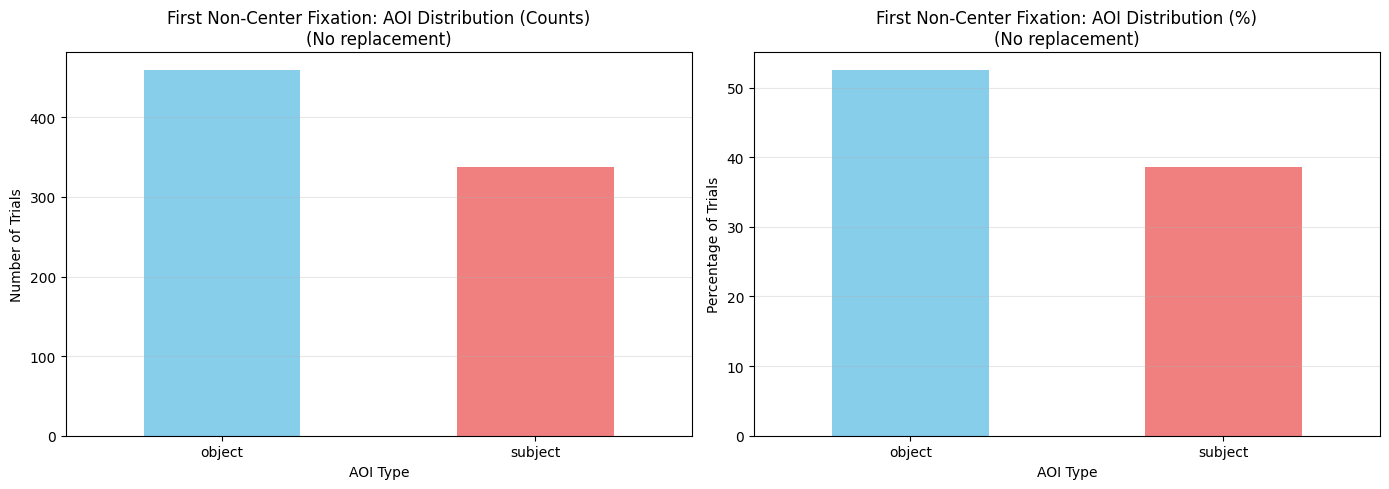

Saved: plots/first_non_center_fixation/aoi_distribution.png


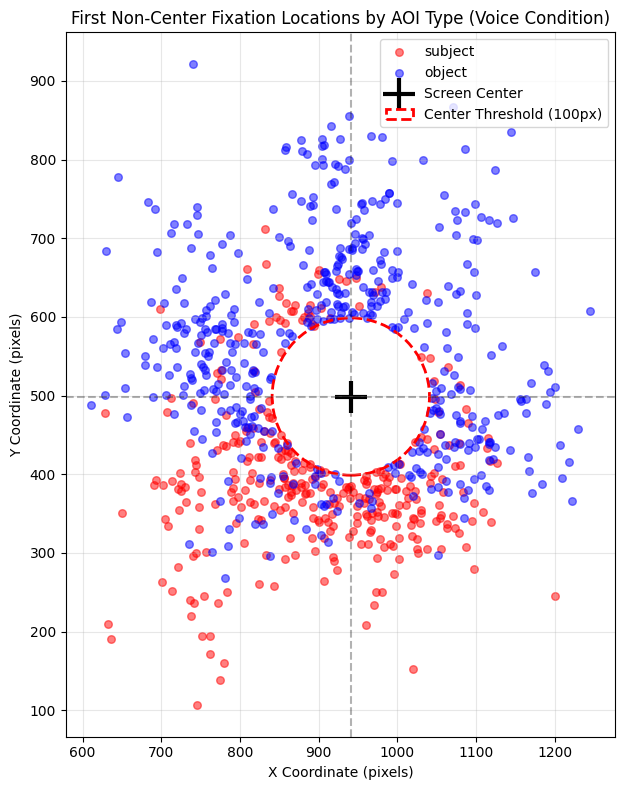

Saved: plots/first_non_center_fixation/locations_by_aoi.png


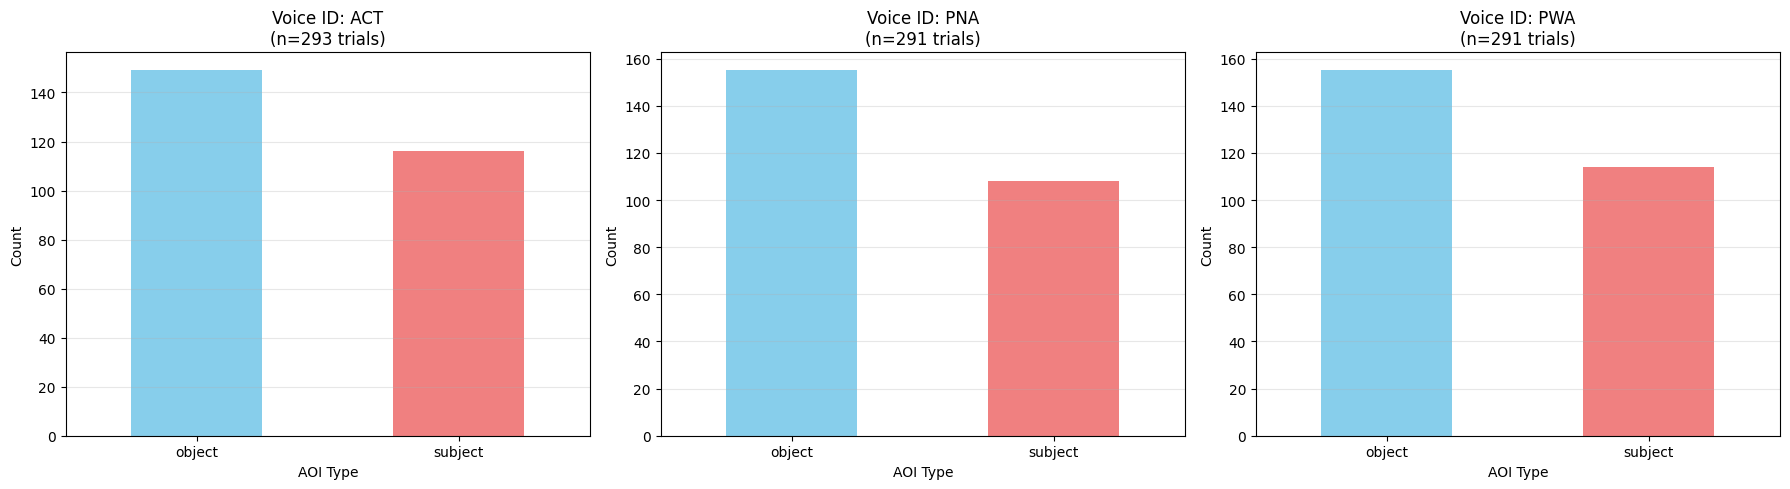

Saved: plots/first_non_center_fixation/aoi_by_voice_id.png

6. STATISTICAL ANALYSIS


ValueError: For each axis slice, the sum of the observed frequencies must agree with the sum of the expected frequencies to a relative tolerance of 1.4901161193847656e-08, but the percent differences are:
0.09786700125470514

In [10]:
# %% First Non-Center Fixation Analysis
# Script: 09_first_non_center_fixation.py
# Purpose: Find first fixation away from center and analyze which AOI is seen first




print("Analyzing First Non-Center Fixation (Voice Condition)...")


# Filter clean data
fixation_clean = merged_fixation_data[~merged_fixation_data['exclude_fixation']].copy()

# Filter for Voice condition only (has voice_id)
voice_data = fixation_clean[
    fixation_clean['voice_id'].notna() & 
    (fixation_clean['voice_id'] != "") & 
    (fixation_clean['voice_id'] != "UNDEFINEDnull")
].copy()

print(f"\nTotal fixations in Voice condition: {len(voice_data)}")
print(f"Unique trials in Voice condition: {voice_data.groupby(['participant_id', 'TRIAL_INDEX']).ngroups}")

# Calculate screen center from all data
x_center = fixation_clean['CURRENT_FIX_X'].median()
y_center = fixation_clean['CURRENT_FIX_Y'].median()
print(f"\nEstimated screen center: X={x_center:.0f}, Y={y_center:.0f}")

# Define center threshold (e.g., within 100 pixels of center)
# We'll test different thresholds
thresholds = [50, 75, 100, 125, 150]

print("\n" + "="*80)
print("TESTING DIFFERENT CENTER THRESHOLDS")
print("="*80)

threshold_results = []

for threshold in thresholds:
    # Calculate distance from center for each fixation
    voice_data['distance_from_center'] = np.sqrt(
        (voice_data['CURRENT_FIX_X'] - x_center)**2 + 
        (voice_data['CURRENT_FIX_Y'] - y_center)**2
    )
    
    # Identify center fixations (within threshold)
    voice_data['is_center'] = voice_data['distance_from_center'] <= threshold
    
    # For each trial, find first non-center fixation
    grouping_cols = ['participant_id', 'TRIAL_INDEX']
    if 'image_id' in voice_data.columns:
        grouping_cols.append('image_id')
    
    first_non_center = []
    
    for name, group in voice_data.groupby(grouping_cols):
        # Sort by fixation start time
        group_sorted = group.sort_values('CURRENT_FIX_START')
        
        # Find first non-center fixation
        non_center_fixations = group_sorted[~group_sorted['is_center']]
        
        if len(non_center_fixations) > 0:
            first_non_center_fix = non_center_fixations.iloc[0]
            first_non_center.append({
                'participant_id': first_non_center_fix['participant_id'],
                'TRIAL_INDEX': first_non_center_fix['TRIAL_INDEX'],
                'image_id': first_non_center_fix.get('image_id', 'unknown'),
                'aoi_type': first_non_center_fix.get('aoi_type', 'unknown'),
                'CURRENT_FIX_X': first_non_center_fix['CURRENT_FIX_X'],
                'CURRENT_FIX_Y': first_non_center_fix['CURRENT_FIX_Y'],
                'distance_from_center': first_non_center_fix['distance_from_center'],
                'CURRENT_FIX_START': first_non_center_fix['CURRENT_FIX_START'],
                'CURRENT_FIX_DURATION': first_non_center_fix['CURRENT_FIX_DURATION'],
                'threshold': threshold
            })
    
    first_non_center_df = pd.DataFrame(first_non_center)
    
    if len(first_non_center_df) > 0:
        # Count AOI types
        aoi_counts = first_non_center_df['aoi_type'].value_counts()
        aoi_pct = first_non_center_df['aoi_type'].value_counts(normalize=True) * 100
        
        threshold_results.append({
            'threshold': threshold,
            'n_trials': len(first_non_center_df),
            'subject_count': aoi_counts.get('subject', 0),
            'subject_pct': aoi_pct.get('subject', 0),
            'object_count': aoi_counts.get('object', 0),
            'object_pct': aoi_pct.get('object', 0),
            'other_count': aoi_counts.get('other', 0),
            'other_pct': aoi_pct.get('other', 0),
            'mean_distance': first_non_center_df['distance_from_center'].mean()
        })
        
        print(f"\nThreshold: {threshold} pixels")
        print(f"  Trials with non-center fixations: {len(first_non_center_df)}")
        print(f"  Mean distance from center: {first_non_center_df['distance_from_center'].mean():.1f} pixels")
        print(f"  AOI distribution:")
        for aoi in ['subject', 'object', 'other']:
            count = aoi_counts.get(aoi, 0)
            pct = aoi_pct.get(aoi, 0)
            print(f"    {aoi}: {count} ({pct:.1f}%)")

threshold_summary = pd.DataFrame(threshold_results)
print("\n" + "="*80)
print("THRESHOLD COMPARISON SUMMARY")
print("="*80)
print(threshold_summary.to_string(index=False))

# Select optimal threshold (e.g., 100 pixels - reasonable distance from center)
selected_threshold = 100
print(f"\nUsing threshold: {selected_threshold} pixels for main analysis")

# Recalculate with selected threshold
voice_data['distance_from_center'] = np.sqrt(
    (voice_data['CURRENT_FIX_X'] - x_center)**2 + 
    (voice_data['CURRENT_FIX_Y'] - y_center)**2
)
voice_data['is_center'] = voice_data['distance_from_center'] <= selected_threshold

# Find first non-center fixation for each trial
print("\n" + "="*80)
print("MAIN ANALYSIS: FIRST NON-CENTER FIXATION (Voice Condition)")
print("="*80)

grouping_cols = ['participant_id', 'TRIAL_INDEX']
if 'image_id' in voice_data.columns:
    grouping_cols.append('image_id')

first_non_center_list = []

for name, group in voice_data.groupby(grouping_cols):
    group_sorted = group.sort_values('CURRENT_FIX_START')
    non_center_fixations = group_sorted[~group_sorted['is_center']]
    
    if len(non_center_fixations) > 0:
        first_fix = non_center_fixations.iloc[0]
        first_non_center_list.append({
            'participant_id': first_fix['participant_id'],
            'TRIAL_INDEX': first_fix['TRIAL_INDEX'],
            'image_id': first_fix.get('image_id', 'unknown'),
            'voice_id': first_fix.get('voice_id', 'unknown'),
            'aoi_type': first_fix.get('aoi_type', 'unknown'),
            'CURRENT_FIX_X': first_fix['CURRENT_FIX_X'],
            'CURRENT_FIX_Y': first_fix['CURRENT_FIX_Y'],
            'distance_from_center': first_fix['distance_from_center'],
            'CURRENT_FIX_START': first_fix['CURRENT_FIX_START'],
            'CURRENT_FIX_DURATION': first_fix['CURRENT_FIX_DURATION'],
            'CURRENT_FIX_INTEREST_AREA_LABEL': first_fix.get('CURRENT_FIX_INTEREST_AREA_LABEL', ''),
        })

first_non_center_df = pd.DataFrame(first_non_center_list)


print(f"\nTotal trials analyzed: {len(first_non_center_df)}")
print(f"Trials with valid AOI: {first_non_center_df['aoi_type'].notna().sum()}")


# 1. AOI DISTRIBUTION
print("\n" + "="*80)
print("1. AOI DISTRIBUTION (First Non-Center Fixation)")
print("="*80)

aoi_counts = first_non_center_df['aoi_type'].value_counts()
aoi_pct = first_non_center_df['aoi_type'].value_counts(normalize=True) * 100

print("\nWhich AOI is seen first (after ignoring center fixations):")

for aoi in ['subject', 'object']:
    count = aoi_counts.get(aoi, 0)
    pct = aoi_pct.get(aoi, 0)
    print(f"  {aoi}: {count} fixations ({pct:.1f}%)")

print(f"\nTotal first non-center fixations: {len(first_non_center_df)}")
print(f"Total subject : {aoi_counts.get('subject', 0)}")
print(f"Total object: {aoi_counts.get('object', 0)}")

aoi_summary = pd.DataFrame({
    'aoi_type': aoi_counts.index,
    'count': aoi_counts.values,
    'percentage': aoi_pct.values
})
aoi_summary.to_csv("results/first_non_center_fixation/aoi_distribution.csv", index=False)

# 2. BY VOICE ID
print("\n" + "="*80)
print("2. AOI DISTRIBUTION BY VOICE ID")
print("="*80)

if 'voice_id' in first_non_center_df.columns:
    voice_aoi = pd.crosstab(first_non_center_df['voice_id'], first_non_center_df['aoi_type'], 
                            normalize='index') * 100
    voice_aoi_counts = pd.crosstab(first_non_center_df['voice_id'], first_non_center_df['aoi_type'])
    
    print("\nAOI Distribution by Voice ID (%):")
    print(voice_aoi.round(1).to_string())
    
    print("\nAOI Distribution by Voice ID (counts):")
    print(voice_aoi_counts.to_string())
    
    voice_aoi.to_csv("results/first_non_center_fixation/aoi_by_voice_id_pct.csv")
    voice_aoi_counts.to_csv("results/first_non_center_fixation/aoi_by_voice_id_counts.csv")

# 3. BY IMAGE
print("\n" + "="*80)
print("3. AOI DISTRIBUTION BY IMAGE")
print("="*80)

if 'image_id' in first_non_center_df.columns:
    image_aoi = pd.crosstab(first_non_center_df['image_id'], first_non_center_df['aoi_type'], 
                           normalize='index') * 100
    image_aoi_counts = pd.crosstab(first_non_center_df['image_id'], first_non_center_df['aoi_type'])
    
    print("\nAOI Distribution by Image (%):")
    print(image_aoi.round(1).to_string())
    
    image_aoi.to_csv("results/first_non_center_fixation/aoi_by_image_pct.csv")
    image_aoi_counts.to_csv("results/first_non_center_fixation/aoi_by_image_counts.csv")

# 4. LOCATION ANALYSIS
print("\n" + "="*80)
print("4. LOCATION OF FIRST NON-CENTER FIXATION")
print("="*80)

location_summary = first_non_center_df.groupby('aoi_type').agg({
    'CURRENT_FIX_X': ['mean', 'median', 'std'],
    'CURRENT_FIX_Y': ['mean', 'median', 'std'],
    'distance_from_center': ['mean', 'median', 'std']
}).round(2)

location_summary.columns = ['_'.join(col).strip() for col in location_summary.columns.values]
location_summary = location_summary.reset_index()

print("\nLocation Statistics by AOI Type:")
print(location_summary.to_string(index=False))

location_summary.to_csv("results/first_non_center_fixation/location_by_aoi.csv", index=False)

# 5. VISUALIZATIONS
print("\n" + "="*80)
print("5. CREATING VISUALIZATIONS")
print("="*80)

plt.style.use('default')
sns.set_palette("Set2")

# 5.1 AOI Distribution Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter to only subject and object
aoi_counts_filtered = aoi_counts[aoi_counts.index.isin(['subject', 'object'])]
aoi_pct_filtered = aoi_pct[aoi_pct.index.isin(['subject', 'object'])]

# Counts
aoi_counts_filtered.plot(kind='bar', ax=axes[0], color=['skyblue', 'lightcoral'])
axes[0].set_title('First Non-Center Fixation: AOI Distribution (Counts)\n(No replacement)')
axes[0].set_xlabel('AOI Type')
axes[0].set_ylabel('Number of Trials')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Percentages
aoi_pct_filtered.plot(kind='bar', ax=axes[1], color=['skyblue', 'lightcoral'])
axes[1].set_title('First Non-Center Fixation: AOI Distribution (%)\n(No replacement)')
axes[1].set_xlabel('AOI Type')
axes[1].set_ylabel('Percentage of Trials')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("plots/first_non_center_fixation/aoi_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/first_non_center_fixation/aoi_distribution.png")

# 5.2 Scatter plot by AOI
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'subject': 'red', 'object': 'blue'}
for aoi in ['subject', 'object']:
    aoi_data = first_non_center_df[first_non_center_df['aoi_type'] == aoi]
    if len(aoi_data) > 0:
        ax.scatter(aoi_data['CURRENT_FIX_X'], aoi_data['CURRENT_FIX_Y'], 
                  alpha=0.5, s=30, label=aoi, c=colors.get(aoi, 'black'))

# Mark center
ax.scatter(x_center, y_center, marker='+', s=500, c='black', linewidths=3, label='Screen Center')
ax.axvline(x_center, color='black', linestyle='--', alpha=0.3)
ax.axhline(y_center, color='black', linestyle='--', alpha=0.3)

# Draw threshold circle
circle = plt.Circle((x_center, y_center), selected_threshold, fill=False, 
                   color='red', linestyle='--', linewidth=2, label=f'Center Threshold ({selected_threshold}px)')
ax.add_patch(circle)

ax.set_title('First Non-Center Fixation Locations by AOI Type (Voice Condition)')
ax.set_xlabel('X Coordinate (pixels)')
ax.set_ylabel('Y Coordinate (pixels)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("plots/first_non_center_fixation/locations_by_aoi.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/first_non_center_fixation/locations_by_aoi.png")

# 5.3 By Voice ID (if available)
if 'voice_id' in first_non_center_df.columns and first_non_center_df['voice_id'].nunique() > 1:
    fig, axes = plt.subplots(1, len(first_non_center_df['voice_id'].unique()), 
                            figsize=(6*first_non_center_df['voice_id'].nunique(), 5))
    
    if first_non_center_df['voice_id'].nunique() == 1:
        axes = [axes]
    
    for idx, voice_id in enumerate(sorted(first_non_center_df['voice_id'].unique())):
        voice_data_subset = first_non_center_df[first_non_center_df['voice_id'] == voice_id]
        aoi_counts_voice = voice_data_subset['aoi_type'].value_counts()
        
        # Filter to only subject and object
        aoi_counts_voice_filtered = aoi_counts_voice[aoi_counts_voice.index.isin(['subject', 'object'])]
        aoi_counts_voice_filtered.plot(kind='bar', ax=axes[idx], color=['skyblue', 'lightcoral'])
        axes[idx].set_title(f'Voice ID: {voice_id}\n(n={len(voice_data_subset)} trials)')
        axes[idx].set_xlabel('AOI Type')
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=0)
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("plots/first_non_center_fixation/aoi_by_voice_id.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: plots/first_non_center_fixation/aoi_by_voice_id.png")

# 6. STATISTICAL TEST
print("\n" + "="*80)
print("6. STATISTICAL ANALYSIS")
print("="*80)

# Test if distribution differs from chance (50% each if equal)
from scipy.stats import chi2_contingency

if len(aoi_counts) >= 2:
    # Chi-square test for uniform distribution (50/50 split)
    expected = np.array([len(first_non_center_df) / 2] * 2)  # Equal distribution
    observed = np.array([aoi_counts.get('subject', 0), 
                        aoi_counts.get('object', 0)])
    
    chi2, p_value = stats.chisquare(observed, expected)
    
    print(f"\nChi-square test (equal distribution):")
    print(f"  Chi-square = {chi2:.3f}")
    print(f"  p-value = {p_value:.4f}")
    if p_value < 0.001:
        print(f"  Result: *** p < 0.001 (distribution is NOT uniform)")
    elif p_value < 0.01:
        print(f"  Result: ** p < 0.01 (distribution is NOT uniform)")
    elif p_value < 0.05:
        print(f"  Result: * p < 0.05 (distribution is NOT uniform)")
    else:
        print(f"  Result: ns (p >= 0.05, distribution could be uniform)")

# 7. SAVE DATA
print("\n" + "="*80)
print("7. SAVING RESULTS")
print("="*80)

first_non_center_df.to_csv("results/first_non_center_fixation/first_non_center_fixations.csv", index=False)
print("Saved: results/first_non_center_fixation/first_non_center_fixations.csv")

# Generate summary report
report_lines = []
report_lines.append("="*80)
report_lines.append("FIRST NON-CENTER FIXATION ANALYSIS (Voice Condition)")
report_lines.append("="*80)
report_lines.append(f"\nGenerated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

report_lines.append("METHOD:")
report_lines.append(f"  - Center threshold: {selected_threshold} pixels from center (X={x_center:.0f}, Y={y_center:.0f})")
report_lines.append(f"  - Analyzed first fixation that is >{selected_threshold} pixels from center")
report_lines.append(f"  - Total trials analyzed: {len(first_non_center_df)}\n")

report_lines.append("KEY FINDING:")
dominant_aoi = aoi_counts.index[0]
dominant_pct = aoi_pct.iloc[0]
report_lines.append(f"  The first non-center fixation lands on '{dominant_aoi}' AOI in {dominant_pct:.1f}% of trials")
report_lines.append(f"  This is the most common first AOI after ignoring center fixations.\n")

report_lines.append("DETAILED DISTRIBUTION:")
report_lines.append("  Note: 'other' AOI has been recategorized as 'subject'")
for aoi in ['subject', 'object']:
    count = aoi_counts.get(aoi, 0)
    pct = aoi_pct.get(aoi, 0)
    report_lines.append(f"  {aoi}: {count} trials ({pct:.1f}%)")

report_text = "\n".join(report_lines)

with open("results/first_non_center_fixation/analysis_report.txt", 'w', encoding='utf-8') as f:
    f.write(report_text)

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated files:")
print("  - results/first_non_center_fixation/first_non_center_fixations.csv")
print("  - results/first_non_center_fixation/aoi_distribution.csv")
print("  - results/first_non_center_fixation/location_by_aoi.csv")
print("  - results/first_non_center_fixation/analysis_report.txt")
print("  - plots/first_non_center_fixation/aoi_distribution.png")
print("  - plots/first_non_center_fixation/locations_by_aoi.png")


## Step 10: Total Fixations by AOI

Counts the total number of fixations inside each AOI (subject vs object) specifically within the Voice condition, breaking down the counts and percentages by Voice ID and Image.


Analyzing Total Fixations by AOI (Voice Condition)...

Total fixations in Voice condition: 12150
Unique trials: 882

1. TOTAL FIXATIONS BY AOI TYPE

Total Fixations by AOI Type:
  subject: 4,789 fixations (39.4%)
  object: 5,706 fixations (47.0%)

Total fixations: 12,150

2. TOTAL FIXATIONS BY VOICE ID AND AOI

Total Fixations by Voice ID and AOI (counts):
aoi_type  object  other  subject
voice_id                        
ACT         1906    598     1688
PNA         1909    568     1506
PWA         1891    489     1595

Total Fixations by Voice ID and AOI (%):
aoi_type  object  other  subject
voice_id                        
ACT         45.5   14.3     40.3
PNA         47.9   14.3     37.8
PWA         47.6   12.3     40.1

Total Fixations by Voice ID (with totals):
aoi_type  object  other  subject  TOTAL
voice_id                               
ACT         1906    598     1688   4192
PNA         1909    568     1506   3983
PWA         1891    489     1595   3975

3. TOTAL FIXATIONS BY IM

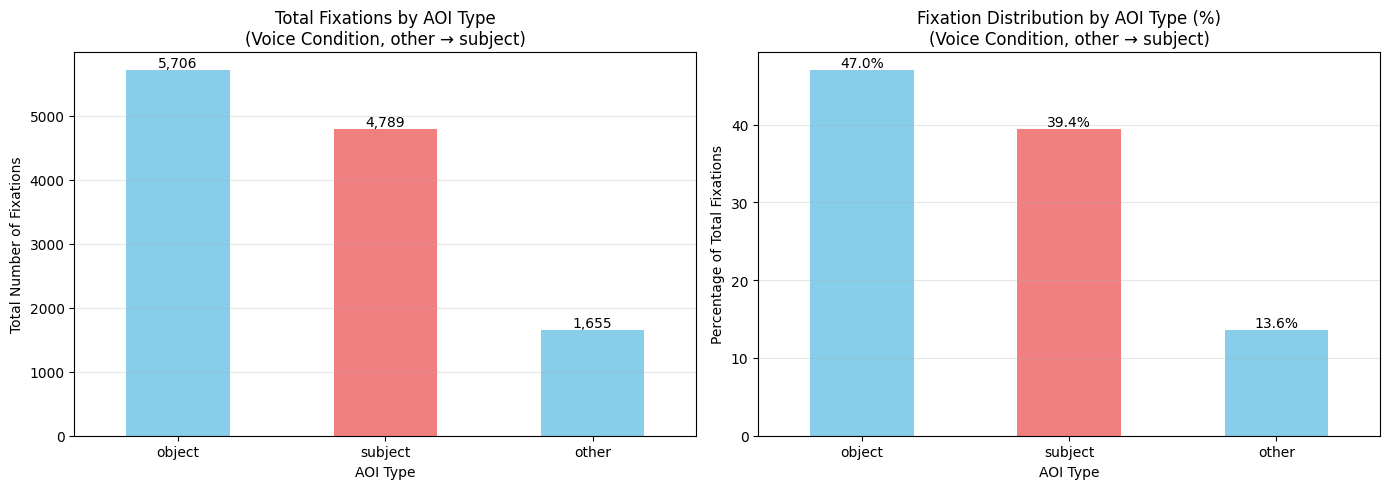

Saved: plots/total_fixations/total_fixations_by_aoi.png


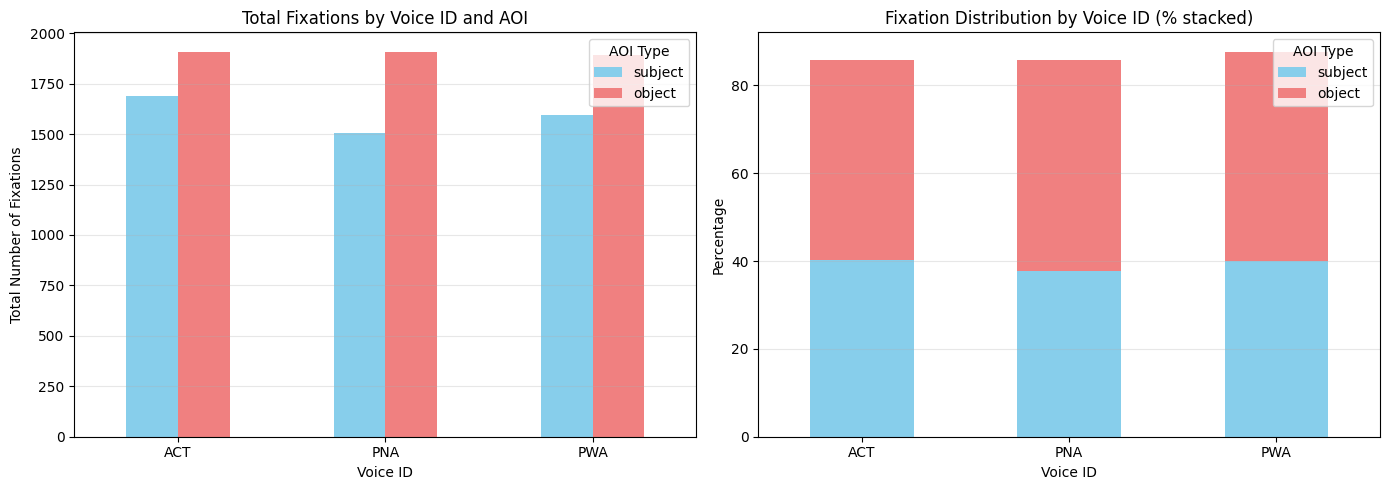

Saved: plots/total_fixations/total_fixations_by_voice_id.png

6. GENERATING SUMMARY REPORT

ANALYSIS COMPLETE!

Generated files:
  - results/total_fixations/total_fixations_by_aoi.csv
  - results/total_fixations/total_fixations_by_voice_aoi_counts.csv
  - results/total_fixations/total_fixations_by_voice_aoi_pct.csv
  - results/total_fixations/average_fixations_per_trial_by_aoi.csv
  - results/total_fixations/total_fixations_report.txt
  - plots/total_fixations/total_fixations_by_aoi.png
  - plots/total_fixations/total_fixations_by_voice_id.png


In [11]:
# %% Total Fixations by AOI Analysis
# Script: 10_total_fixations_by_aoi.py
# Purpose: Analyze total number of fixations by AOI type for Voice condition




print("Analyzing Total Fixations by AOI (Voice Condition)...")


# Filter clean data for Voice condition only
fixation_clean = merged_fixation_data[~merged_fixation_data['exclude_fixation']].copy()

voice_data = fixation_clean[
    fixation_clean['voice_id'].notna() & 
    (fixation_clean['voice_id'] != "") & 
    (fixation_clean['voice_id'] != "UNDEFINEDnull")
].copy()


print(f"\nTotal fixations in Voice condition: {len(voice_data)}")
print(f"Unique trials: {voice_data.groupby(['participant_id', 'TRIAL_INDEX']).ngroups}")

# 1. TOTAL FIXATIONS BY AOI TYPE
print("\n" + "="*80)
print("1. TOTAL FIXATIONS BY AOI TYPE")
print("="*80)

aoi_totals = voice_data['aoi_type'].value_counts()
aoi_totals_pct = voice_data['aoi_type'].value_counts(normalize=True) * 100

print("\nTotal Fixations by AOI Type:")
for aoi in ['subject', 'object']:
    count = aoi_totals.get(aoi, 0)
    pct = aoi_totals_pct.get(aoi, 0)
    print(f"  {aoi}: {count:,} fixations ({pct:.1f}%)")

print(f"\nTotal fixations: {len(voice_data):,}")

total_summary = pd.DataFrame({
    'aoi_type': aoi_totals.index,
    'total_fixations': aoi_totals.values,
    'percentage': aoi_totals_pct.values
})
total_summary.to_csv("results/total_fixations/total_fixations_by_aoi.csv", index=False)

# 2. TOTAL FIXATIONS BY VOICE ID
print("\n" + "="*80)
print("2. TOTAL FIXATIONS BY VOICE ID AND AOI")
print("="*80)

voice_aoi_totals = pd.crosstab(voice_data['voice_id'], voice_data['aoi_type'])
voice_aoi_totals_pct = pd.crosstab(voice_data['voice_id'], voice_data['aoi_type'], normalize='index') * 100

print("\nTotal Fixations by Voice ID and AOI (counts):")
print(voice_aoi_totals.to_string())

print("\nTotal Fixations by Voice ID and AOI (%):")
print(voice_aoi_totals_pct.round(1).to_string())

voice_aoi_totals.to_csv("results/total_fixations/total_fixations_by_voice_aoi_counts.csv")
voice_aoi_totals_pct.to_csv("results/total_fixations/total_fixations_by_voice_aoi_pct.csv")

# Add row totals
voice_aoi_totals['TOTAL'] = voice_aoi_totals.sum(axis=1)
print("\nTotal Fixations by Voice ID (with totals):")
print(voice_aoi_totals.to_string())

# 3. TOTAL FIXATIONS BY IMAGE
print("\n" + "="*80)
print("3. TOTAL FIXATIONS BY IMAGE AND AOI")
print("="*80)

if 'image_id' in voice_data.columns:
    image_aoi_totals = pd.crosstab(voice_data['image_id'], voice_data['aoi_type'])
    image_aoi_totals_pct = pd.crosstab(voice_data['image_id'], voice_data['aoi_type'], normalize='index') * 100
    
    image_aoi_totals['TOTAL'] = image_aoi_totals.sum(axis=1)
    
    print("\nTotal Fixations by Image and AOI (sample - first 10 images):")
    print(image_aoi_totals.head(10).to_string())
    
    print("\n...")
    print(f"\nTotal fixations across all images: {image_aoi_totals['TOTAL'].sum():,}")
    
    image_aoi_totals.to_csv("results/total_fixations/total_fixations_by_image_aoi_counts.csv")
    image_aoi_totals_pct.to_csv("results/total_fixations/total_fixations_by_image_aoi_pct.csv")

# 4. TRIAL-LEVEL SUMMARY
print("\n" + "="*80)
print("4. AVERAGE FIXATIONS PER TRIAL BY AOI")
print("="*80)

trial_aoi_summary = voice_data.groupby(['participant_id', 'TRIAL_INDEX', 'aoi_type']).size().reset_index(name='fixation_count')
trial_summary = trial_aoi_summary.groupby('aoi_type')['fixation_count'].agg(['mean', 'median', 'std', 'count']).round(2)

print("\nAverage Fixations per Trial by AOI:")
print(trial_summary.to_string())

trial_summary.to_csv("results/total_fixations/average_fixations_per_trial_by_aoi.csv")

# 5. VISUALIZATIONS
print("\n" + "="*80)
print("5. CREATING VISUALIZATIONS")
print("="*80)

plt.style.use('default')
sns.set_palette("Set2")

# 5.1 Total fixations bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
aoi_totals.plot(kind='bar', ax=axes[0], color=['skyblue', 'lightcoral'])
axes[0].set_title('Total Fixations by AOI Type\n(Voice Condition, other → subject)')
axes[0].set_xlabel('AOI Type')
axes[0].set_ylabel('Total Number of Fixations')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(aoi_totals.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# Percentages
aoi_totals_pct.plot(kind='bar', ax=axes[1], color=['skyblue', 'lightcoral'])
axes[1].set_title('Fixation Distribution by AOI Type (%)\n(Voice Condition, other → subject)')
axes[1].set_xlabel('AOI Type')
axes[1].set_ylabel('Percentage of Total Fixations')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(aoi_totals_pct.values):
    axes[1].text(i, v, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig("plots/total_fixations/total_fixations_by_aoi.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/total_fixations/total_fixations_by_aoi.png")

# 5.2 By Voice ID
if len(voice_aoi_totals) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Counts
    voice_aoi_totals[['subject', 'object']].plot(kind='bar', ax=axes[0], 
                                                  color=['skyblue', 'lightcoral'])
    axes[0].set_title('Total Fixations by Voice ID and AOI')
    axes[0].set_xlabel('Voice ID')
    axes[0].set_ylabel('Total Number of Fixations')
    axes[0].legend(title='AOI Type')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Percentages
    voice_aoi_totals_pct[['subject', 'object']].plot(kind='bar', ax=axes[1], 
                                                     color=['skyblue', 'lightcoral'], stacked=True)
    axes[1].set_title('Fixation Distribution by Voice ID (% stacked)')
    axes[1].set_xlabel('Voice ID')
    axes[1].set_ylabel('Percentage')
    axes[1].legend(title='AOI Type')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("plots/total_fixations/total_fixations_by_voice_id.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: plots/total_fixations/total_fixations_by_voice_id.png")

# 6. GENERATE SUMMARY REPORT
print("\n" + "="*80)
print("6. GENERATING SUMMARY REPORT")
print("="*80)

report_lines = []
report_lines.append("="*80)
report_lines.append("TOTAL FIXATIONS BY AOI ANALYSIS (Voice Condition)")
report_lines.append("="*80)
report_lines.append(f"\nGenerated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

report_lines.append("NOTE: 'other' AOI has been recategorized as 'subject'\n")

report_lines.append("SUMMARY:")
report_lines.append(f"  Total fixations analyzed: {len(voice_data):,}")
report_lines.append(f"  Total trials: {voice_data.groupby(['participant_id', 'TRIAL_INDEX']).ngroups}\n")

report_lines.append("TOTAL FIXATIONS BY AOI TYPE:")
for aoi in ['subject', 'object']:
    count = aoi_totals.get(aoi, 0)
    pct = aoi_totals_pct.get(aoi, 0)
    report_lines.append(f"  {aoi}: {count:,} fixations ({pct:.1f}%)")

report_lines.append("\nTOTAL FIXATIONS BY VOICE ID:")
for voice_id in voice_aoi_totals.index:
    report_lines.append(f"\n  {voice_id}:")
    total_voice = voice_aoi_totals.loc[voice_id, 'TOTAL'] if 'TOTAL' in voice_aoi_totals.columns else voice_aoi_totals.loc[voice_id].sum()
    report_lines.append(f"    Total fixations: {total_voice:,}")
    for aoi in ['subject', 'object']:
        if aoi in voice_aoi_totals.columns:
            count = voice_aoi_totals.loc[voice_id, aoi]
            pct = voice_aoi_totals_pct.loc[voice_id, aoi]
            report_lines.append(f"    {aoi}: {count:,} ({pct:.1f}%)")

report_lines.append("\nAVERAGE FIXATIONS PER TRIAL:")
for aoi in trial_summary.index:
    mean = trial_summary.loc[aoi, 'mean']
    median = trial_summary.loc[aoi, 'median']
    report_lines.append(f"  {aoi}: M={mean:.2f}, Median={median:.2f}")

report_text = "\n".join(report_lines)

with open("results/total_fixations/total_fixations_report.txt", 'w', encoding='utf-8') as f:
    f.write(report_text)

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated files:")
print("  - results/total_fixations/total_fixations_by_aoi.csv")
print("  - results/total_fixations/total_fixations_by_voice_aoi_counts.csv")
print("  - results/total_fixations/total_fixations_by_voice_aoi_pct.csv")
print("  - results/total_fixations/average_fixations_per_trial_by_aoi.csv")
print("  - results/total_fixations/total_fixations_report.txt")
print("  - plots/total_fixations/total_fixations_by_aoi.png")
print("  - plots/total_fixations/total_fixations_by_voice_id.png")


## Step 11: Active/Passive Voice and First Fixation Correlation

Investigates the core linguistic hypothesis by correlating voice type (Active vs. Passive) with the first non-center fixation AOI. Runs Chi-square tests of independence, Fisher's exact tests, and logistic regression.


Analyzing Active/Passive Voice and First Fixation Correlation...

Total first non-center fixations: 875
Unique voice_id values: ['PNA' 'ACT' 'PWA']

VOICE ID VALUES AND DISTRIBUTION

Voice ID distribution:
voice_id
ACT    293
PNA    291
PWA    291
Name: count, dtype: int64

Voice Type Category distribution:
voice_type_category
Passive    582
Active     293
Name: count, dtype: int64

Data for analysis (Active + Passive): 875 trials

1. CROSS-TABULATION: VOICE TYPE vs FIRST FIXATION AOI

Contingency Table (Counts):
aoi_type             object  subject
voice_type_category                 
Active                  149      144
Passive                 310      272

Row totals:
voice_type_category
Active     293
Passive    582
dtype: int64

Contingency Table (Row Percentages):
aoi_type             object  subject
voice_type_category                 
Active                 50.9     49.1
Passive                53.3     46.7

2. STATISTICAL TESTS

Chi-square Test of Independence:
  Chi-square st

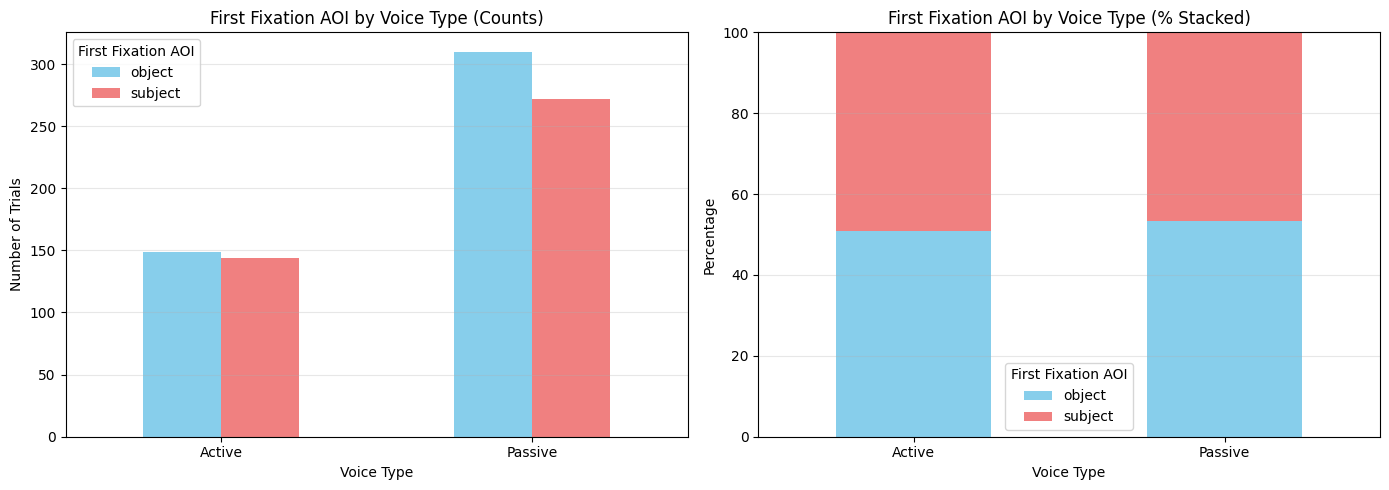

Saved: plots/active_passive_correlation/first_fixation_by_voice_type.png


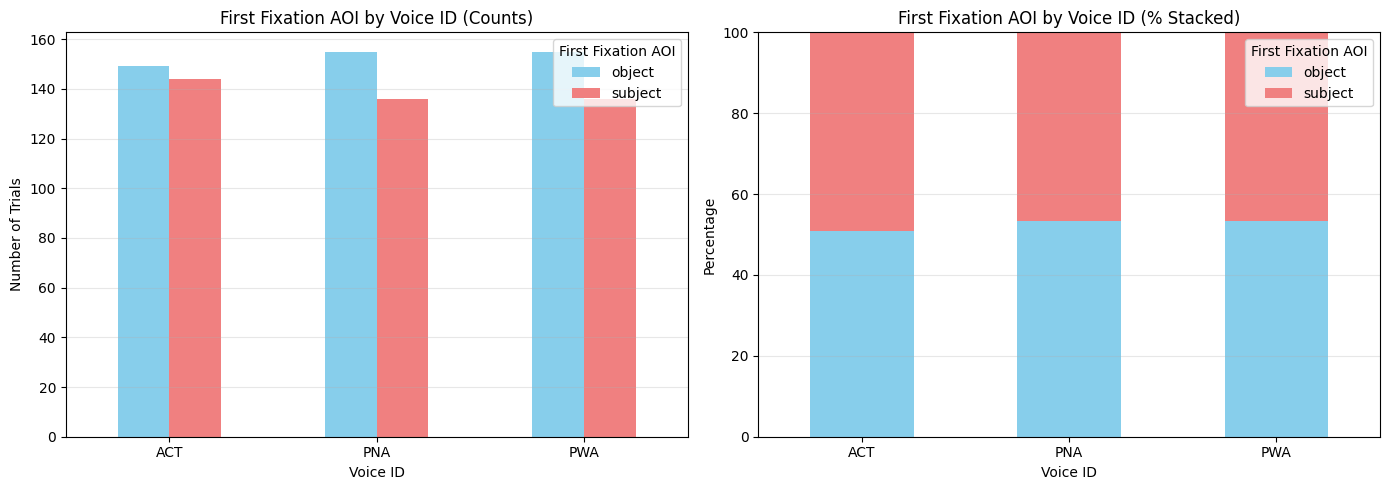

Saved: plots/active_passive_correlation/first_fixation_by_voice_id_detailed.png

5. LOGISTIC REGRESSION ANALYSIS

Logistic Regression Results:
  Coefficient (voice_type): -0.0947
  Intercept: 0.1301
  Odds Ratio: 0.9096
  Interpretation: Active voice decreases odds of object fixation
  Model Accuracy: 0.525

6. GENERATING REPORT

ANALYSIS COMPLETE!

Generated files:
  - results/active_passive_correlation/contingency_table_counts.csv
  - results/active_passive_correlation/contingency_table_percentages.csv
  - results/active_passive_correlation/correlation_analysis_report.txt
  - plots/active_passive_correlation/first_fixation_by_voice_type.png
  - plots/active_passive_correlation/first_fixation_by_voice_id_detailed.png


In [12]:
# %% Active/Passive Voice and First Fixation Correlation Analysis
# Script: 11_active_passive_first_fixation_correlation.py
# Patch from removed read_csv: use dataframe from Step 9 directly in memory
first_non_center = first_non_center_df.copy()
# Purpose: Analyze correlation between voice type (active/passive) and first fixation AOI




print("Analyzing Active/Passive Voice and First Fixation Correlation...")


# Recategorize "other" as "subject" if not already done
if 'aoi_type' in first_non_center.columns:
    first_non_center['aoi_type'] = first_non_center['aoi_type'].replace('other', 'subject')

print(f"\nTotal first non-center fixations: {len(first_non_center)}")
print(f"Unique voice_id values: {first_non_center['voice_id'].unique()}")

# Map voice_id to active/passive
# Based on common naming: ACT = Active, PNA/PWA might be Passive
# We'll need to infer or check - let's check the patterns first
print("\n" + "="*80)
print("VOICE ID VALUES AND DISTRIBUTION")
print("="*80)

voice_counts = first_non_center['voice_id'].value_counts()
print("\nVoice ID distribution:")
print(voice_counts)

# Create voice type mapping (ACT = Active, others = Passive, or check patterns)
# Let's assume ACT is Active and PNA/PWA are Passive variants
# If we need to check more, we can analyze sentence structure

# Create active/passive categorization
def categorize_voice_type(voice_id):
    """Categorize voice_id as Active or Passive."""
    voice_id_str = str(voice_id).upper()
    if 'ACT' in voice_id_str or 'ACTIVE' in voice_id_str:
        return 'Active'
    elif 'PNA' in voice_id_str or 'PWA' in voice_id_str or 'PASSIVE' in voice_id_str:
        return 'Passive'
    else:
        return 'Unknown'

first_non_center['voice_type_category'] = first_non_center['voice_id'].apply(categorize_voice_type)

print("\nVoice Type Category distribution:")
print(first_non_center['voice_type_category'].value_counts())

# Filter to only Active and Passive
analysis_data = first_non_center[first_non_center['voice_type_category'].isin(['Active', 'Passive'])].copy()

print(f"\nData for analysis (Active + Passive): {len(analysis_data)} trials")

# 1. CROSS-TABULATION ANALYSIS
print("\n" + "="*80)
print("1. CROSS-TABULATION: VOICE TYPE vs FIRST FIXATION AOI")
print("="*80)

# Create contingency table
contingency_table = pd.crosstab(analysis_data['voice_type_category'], analysis_data['aoi_type'])
print("\nContingency Table (Counts):")
print(contingency_table)
print("\nRow totals:")
print(contingency_table.sum(axis=1))

# Percentage by row
contingency_table_pct = pd.crosstab(analysis_data['voice_type_category'], analysis_data['aoi_type'], 
                                   normalize='index') * 100
print("\nContingency Table (Row Percentages):")
print(contingency_table_pct.round(1))

contingency_table.to_csv("results/active_passive_correlation/contingency_table_counts.csv")
contingency_table_pct.to_csv("results/active_passive_correlation/contingency_table_percentages.csv")

# 2. STATISTICAL TESTS
print("\n" + "="*80)
print("2. STATISTICAL TESTS")
print("="*80)

# Chi-square test of independence
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nChi-square Test of Independence:")
print(f"  Chi-square statistic: {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value: {p_value:.4f}")
print(f"  Expected frequencies:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).round(2))

if p_value < 0.001:
    print(f"\n  Result: *** p < 0.001 (Strong evidence of association)")
elif p_value < 0.01:
    print(f"\n  Result: ** p < 0.01 (Evidence of association)")
elif p_value < 0.05:
    print(f"\n  Result: * p < 0.05 (Evidence of association)")
else:
    print(f"\n  Result: ns (p >= 0.05, no significant association)")

# Effect size: Cramér's V
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"\nEffect Size (Cramér's V): {cramers_v:.4f}")
if cramers_v < 0.1:
    print("  Interpretation: Negligible effect")
elif cramers_v < 0.3:
    print("  Interpretation: Small effect")
elif cramers_v < 0.5:
    print("  Interpretation: Medium effect")
else:
    print("  Interpretation: Large effect")

# Fisher's exact test (for 2x2 tables)
if contingency_table.shape == (2, 2):
    oddsratio, p_value_fisher = fisher_exact(contingency_table)
    print(f"\nFisher's Exact Test:")
    print(f"  Odds ratio: {oddsratio:.4f}")
    print(f"  p-value: {p_value_fisher:.4f}")
    
    if oddsratio > 1:
        print(f"  Interpretation: {oddsratio:.2f}x more likely for Active voice to fixate first AOI")
    else:
        print(f"  Interpretation: {1/oddsratio:.2f}x more likely for Passive voice to fixate first AOI")

# 3. DETAILED BREAKDOWN BY VOICE ID
print("\n" + "="*80)
print("3. DETAILED BREAKDOWN BY SPECIFIC VOICE ID")
print("="*80)

# Compare ACT vs Passive (PNA + PWA combined, or separately)
voice_aoi_detailed = pd.crosstab(first_non_center['voice_id'], first_non_center['aoi_type'])
voice_aoi_detailed_pct = pd.crosstab(first_non_center['voice_id'], first_non_center['aoi_type'], 
                                     normalize='index') * 100

print("\nFirst Fixation AOI by Voice ID (counts):")
print(voice_aoi_detailed)

print("\nFirst Fixation AOI by Voice ID (%):")
print(voice_aoi_detailed_pct.round(1))

# Compare ACT (Active) vs combined Passive
if 'ACT' in first_non_center['voice_id'].values:
    active_data = first_non_center[first_non_center['voice_id'] == 'ACT']
    passive_data = first_non_center[first_non_center['voice_id'].isin(['PNA', 'PWA'])]
    
    print(f"\nACT (Active) voice:")
    print(f"  Total trials: {len(active_data)}")
    active_aoi = active_data['aoi_type'].value_counts(normalize=True) * 100
    for aoi in ['subject', 'object']:
        pct = active_aoi.get(aoi, 0)
        print(f"  {aoi}: {pct:.1f}%")
    
    print(f"\nPNA/PWA (Passive) voices combined:")
    print(f"  Total trials: {len(passive_data)}")
    passive_aoi = passive_data['aoi_type'].value_counts(normalize=True) * 100
    for aoi in ['subject', 'object']:
        pct = passive_aoi.get(aoi, 0)
        print(f"  {aoi}: {pct:.1f}%")

# 4. VISUALIZATIONS
print("\n" + "="*80)
print("4. CREATING VISUALIZATIONS")
print("="*80)

plt.style.use('default')
sns.set_palette("Set2")

# 4.1 Stacked bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
contingency_table.plot(kind='bar', stacked=False, ax=axes[0], 
                       color=['skyblue', 'lightcoral'])
axes[0].set_title('First Fixation AOI by Voice Type (Counts)')
axes[0].set_xlabel('Voice Type')
axes[0].set_ylabel('Number of Trials')
axes[0].legend(title='First Fixation AOI')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Percentages (stacked)
contingency_table_pct.plot(kind='bar', stacked=True, ax=axes[1], 
                           color=['skyblue', 'lightcoral'])
axes[1].set_title('First Fixation AOI by Voice Type (% Stacked)')
axes[1].set_xlabel('Voice Type')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='First Fixation AOI')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig("plots/active_passive_correlation/first_fixation_by_voice_type.png", 
           dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/active_passive_correlation/first_fixation_by_voice_type.png")

# 4.2 Detailed breakdown by specific voice IDs
if len(voice_aoi_detailed) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    voice_aoi_detailed.plot(kind='bar', ax=axes[0], color=['skyblue', 'lightcoral'])
    axes[0].set_title('First Fixation AOI by Voice ID (Counts)')
    axes[0].set_xlabel('Voice ID')
    axes[0].set_ylabel('Number of Trials')
    axes[0].legend(title='First Fixation AOI')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].grid(axis='y', alpha=0.3)
    
    voice_aoi_detailed_pct.plot(kind='bar', stacked=True, ax=axes[1], 
                                color=['skyblue', 'lightcoral'])
    axes[1].set_title('First Fixation AOI by Voice ID (% Stacked)')
    axes[1].set_xlabel('Voice ID')
    axes[1].set_ylabel('Percentage')
    axes[1].legend(title='First Fixation AOI')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig("plots/active_passive_correlation/first_fixation_by_voice_id_detailed.png", 
               dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: plots/active_passive_correlation/first_fixation_by_voice_id_detailed.png")

# 5. LOGISTIC REGRESSION (if we have enough data)
print("\n" + "="*80)
print("5. LOGISTIC REGRESSION ANALYSIS")
print("="*80)

# Create binary outcome (1 = object, 0 = subject)
analysis_data['aoi_binary'] = (analysis_data['aoi_type'] == 'object').astype(int)
analysis_data['voice_binary'] = (analysis_data['voice_type_category'] == 'Active').astype(int)

# Simple logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = analysis_data[['voice_binary']].values
y = analysis_data['aoi_binary'].values

if len(np.unique(y)) > 1:  # Need variation in outcome
    model = LogisticRegression()
    model.fit(X, y)
    
    # Predictions
    y_pred = model.predict(X)
    proba = model.predict_proba(X)
    
    print(f"\nLogistic Regression Results:")
    print(f"  Coefficient (voice_type): {model.coef_[0][0]:.4f}")
    print(f"  Intercept: {model.intercept_[0]:.4f}")
    print(f"  Odds Ratio: {np.exp(model.coef_[0][0]):.4f}")
    
    if model.coef_[0][0] > 0:
        print(f"  Interpretation: Active voice increases odds of object fixation")
    else:
        print(f"  Interpretation: Active voice decreases odds of object fixation")
    
    # Model accuracy
    accuracy = (y_pred == y).mean()
    print(f"  Model Accuracy: {accuracy:.3f}")

# 6. GENERATE COMPREHENSIVE REPORT
print("\n" + "="*80)
print("6. GENERATING REPORT")
print("="*80)

report_lines = []
report_lines.append("="*80)
report_lines.append("ACTIVE/PASSIVE VOICE AND FIRST FIXATION CORRELATION ANALYSIS")
report_lines.append("="*80)
report_lines.append(f"\nGenerated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

report_lines.append("HYPOTHESIS:")
report_lines.append("  Testing whether active vs passive voice influences which AOI")
report_lines.append("  receives the first non-center fixation.\n")

report_lines.append("DATA:")
report_lines.append(f"  Total trials analyzed: {len(analysis_data)}")
report_lines.append(f"  Active voice trials: {len(analysis_data[analysis_data['voice_type_category'] == 'Active'])}")
report_lines.append(f"  Passive voice trials: {len(analysis_data[analysis_data['voice_type_category'] == 'Passive'])}\n")

report_lines.append("CONTINGENCY TABLE:")
report_lines.append(contingency_table.to_string())
report_lines.append("\n")

report_lines.append("ROW PERCENTAGES:")
report_lines.append(contingency_table_pct.round(1).to_string())
report_lines.append("\n")

report_lines.append("STATISTICAL RESULTS:")
report_lines.append(f"  Chi-square test: χ² = {chi2:.4f}, p = {p_value:.4f}")
if p_value < 0.05:
    report_lines.append(f"  Result: SIGNIFICANT association between voice type and first fixation AOI")
else:
    report_lines.append(f"  Result: NO significant association between voice type and first fixation AOI")

report_lines.append(f"  Effect size (Cramér's V): {cramers_v:.4f}")
report_lines.append(f"  Interpretation: {('Small' if cramers_v < 0.3 else 'Medium' if cramers_v < 0.5 else 'Large')} effect size\n")

report_lines.append("KEY FINDINGS:")
if p_value < 0.05:
    # Find which AOI is more common for each voice type
    active_pref = contingency_table_pct.loc['Active'].idxmax()
    passive_pref = contingency_table_pct.loc['Passive'].idxmax()
    active_pct = contingency_table_pct.loc['Active', active_pref]
    passive_pct = contingency_table_pct.loc['Passive', passive_pref]
    
    report_lines.append(f"  1. Active voice: {active_pct:.1f}% first fixate on {active_pref} AOI")
    report_lines.append(f"  2. Passive voice: {passive_pct:.1f}% first fixate on {passive_pref} AOI")
    
    if active_pref != passive_pref:
        report_lines.append(f"  3. Voice type influences first fixation pattern")
else:
    report_lines.append("  1. No significant difference in first fixation patterns between Active and Passive voice")
    report_lines.append("  2. First fixation AOI distribution is similar regardless of voice type")

report_text = "\n".join(report_lines)

with open("results/active_passive_correlation/correlation_analysis_report.txt", 'w', encoding='utf-8') as f:
    f.write(report_text)

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated files:")
print("  - results/active_passive_correlation/contingency_table_counts.csv")
print("  - results/active_passive_correlation/contingency_table_percentages.csv")
print("  - results/active_passive_correlation/correlation_analysis_report.txt")
print("  - plots/active_passive_correlation/first_fixation_by_voice_type.png")
print("  - plots/active_passive_correlation/first_fixation_by_voice_id_detailed.png")

# Save statistical results
stats_results = pd.DataFrame({
    'test': ['Chi-square', 'Cramér\'s V'],
    'value': [chi2, cramers_v],
    'p_value': [p_value, np.nan],
    'interpretation': [
        f"{'Significant' if p_value < 0.05 else 'Not significant'} (p={p_value:.4f})",
        f"{'Small' if cramers_v < 0.3 else 'Medium' if cramers_v < 0.5 else 'Large'} effect"
    ]
})
stats_results.to_csv("results/active_passive_correlation/statistical_test_results.csv", index=False)
